# Needed for all runs

In [7]:
# Pip installs as needed
"""
%pip install torch --index-url https://download.pytorch.org/whl/cpu
%pip install numpy pandas scikit-learn scipy tqdm einops pyyaml matplotlib
%pip install cartopy --quiet
#%pip install 'missing packages'

# Make sure you have CUDA if you have a GPU
%pip uninstall torch torchvision torchaudio -y
%pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu128
"""
# Imports 
import importlib
import os
import torch
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import subprocess
import pandas as pd
import numpy as np
import glob
import pickle
import shutil
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

The bellow block needs to be custimised to the run you are running.
Make sure this is aproperit for your goals **before continueing**

In [ ]:
# The project file paths
PROJECT_ROOT = "C:/Project/"    # The directory of the curent project
# Your data will need to be in a folder called CustomData in the same path as PROJECT_ROOT

# Timing limits 
Paper_hour = 5                  # How long oyu want to spend trainign and testing the model on the orginal paper's data
Our_hour = 5                    # How long you want to spend training and testing the model on the new east cost data
# 5 hours should let everything run on a GPU neds longer for CPUs

# Misc Settings
chosen_idx = 0                  # If you have maltiple data files change this to slect wich to use. 
                                    # 0 will be the first, keep on 0 if you only have 1 file
                                    # You can see which files are loading in wich order in the block this var is used

                    

## Clone repo if needed

In [ ]:
PROJECT_DIR = os.path.join(PROJECT_ROOT, "TrAISformer")

if not os.path.exists(PROJECT_DIR):
    os.system(f"git clone https://github.com/CIA-Oceanix/TrAISformer.git {PROJECT_DIR}")
else:
    print("Repo already present, skipping clone.")

# Extra imports taht depend on the repo being here
os.chdir(PROJECT_DIR)
import config_trAISformer as config
import models
import trainers
import datasets
import utils

print("Working directory:", os.getcwd())
print("GPU found:", torch.cuda.is_available())

Repo already present, skipping clone.
Working directory: C:\Project\TrAISformer
GPU found: True


In [9]:
# Make 2 sets of needed files 
#   one for "the papers data" that is untouched and 
#   one for "our data" that we will need to adjust

paper_cfg = os.path.join(PROJECT_DIR, "config_paper.py")
custom_cfg = os.path.join(PROJECT_DIR, "config_custom.py")

if not os.path.exists(paper_cfg):
    original_text = subprocess.run(
        ["git", "show", "HEAD:config_trAISformer.py"],
        cwd=PROJECT_DIR, capture_output=True, text=True, check=True
    ).stdout
    with open(paper_cfg, "w") as f:
        f.write(original_text)
    print("Recovered pristine paper config from git -> config_paper.py")
else:
    print("config_paper.py already exists, leaving it alone.")

if not os.path.exists(custom_cfg):
    shutil.copy(paper_cfg, custom_cfg)
    print("Seeded config_custom.py from the paper config.")

with open(paper_cfg, "r") as f:
    paper_text = f.read()

if "pred_err_v_ranges" not in paper_text:
    paper_text += (
        "\n\n"
        "# Lets trAISformer.py's own prediction_error.png be swapped per-run\n"
        "# without duplicating the training script. Values match what was\n"
        "# already hardcoded there, so paper behavior is unchanged.\n"
        "pred_err_v_ranges = (2, 3, 0, 0)\n"
        "pred_err_lon_min = -7\n"
        "pred_err_horizon_steps = 6 * 4\n"
        "pred_err_fixed_axes = True\n"
        "pred_err_xlim_hours = 12\n"
        "pred_err_ylim_km = 20\n"
    )
    with open(paper_cfg, "w") as f:
        f.write(paper_text)
    print("Added prediction_error.png fields to config_paper.py")


config_paper.py already exists, leaving it alone.


## Add needed fixes if they have not already been added
*Due to orginal work being done on older vertoins of python and packages*

In [10]:
# fix 1: Check if you have a GPU and change to CPU if needed
def apply_device_fix():
    cfg_path = os.path.join(PROJECT_DIR, "config_trAISformer.py")
    with open("config_trAISformer.py", "r") as f:
        content = f.read()

    if 'device = torch.device("cuda:0")' in content:
        content = content.replace(
            'device = torch.device("cuda:0")',
            'device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")'
        )
        with open("config_trAISformer.py", "w") as f:
            f.write(content)
        print("Patched config_trAISformer.py for device auto-detect.")
    else:
        print("config_trAISformer.py already patched or pattern not found: check manually if training fails on device.")


def activate_config(source_path):
    cfg_path = os.path.join(PROJECT_DIR, "config_trAISformer.py")
    shutil.copy(source_path, cfg_path)
    apply_device_fix()
    importlib.reload(config)
    return config.Config()

# fix 2: fix deprecated .next() call
with open("trainers.py", "r") as f:
    content = f.read()

old = 'iter(aisdls["test"]).next()'
new = 'next(iter(aisdls["test"]))'
if old in content:
    content = content.replace(old, new)
    with open("trainers.py", "w") as f:
        f.write(content)
    print("Patched trainers.py .next() call.")
else:
    print("trainers.py already patched or pattern not found.")

# fix 3: fix deprecated plt.cm.get_cmap()
with open("trainers.py", "r") as f:
    content = f.read()

old = 'plt.cm.get_cmap("jet")'
new = 'plt.get_cmap("jet")'
if old in content:
    content = content.replace(old, new)
    with open("trainers.py", "w") as f:
        f.write(content)
    print("Patched trainers.py get_cmap call.")
else:
    print("trainers.py get_cmap already patched or pattern not found.")

# fix 4: make some fixes to trAISformer.py's prediction_error.png for the data shape we are using in OUR data 
with open("trAISformer.py", "r") as f:
    content = f.read()

old = 'v_ranges = torch.tensor([2, 3, 0, 0]).to(cf.device)\n    v_roi_min = torch.tensor([model.lat_min, -7, 0, 0]).to(cf.device)\n    max_seqlen = init_seqlen + 6 * 4'
new = 'v_ranges = torch.tensor(cf.pred_err_v_ranges).to(cf.device)\n    v_roi_min = torch.tensor([model.lat_min, cf.pred_err_lon_min, 0, 0]).to(cf.device)\n    max_seqlen = init_seqlen + cf.pred_err_horizon_steps'
if old in content:
    content = content.replace(old, new)
    print("Patched trAISformer.py ROI/horizon for prediction_error.png.")
else:
    print("trAISformer.py ROI/horizon already patched or pattern not found.")

old2 = 'plt.xlim([0, 12])\n    plt.ylim([0, 20])'
new2 = 'if cf.pred_err_fixed_axes:\n        plt.xlim([0, cf.pred_err_xlim_hours])\n        plt.ylim([0, cf.pred_err_ylim_km])'
if old2 in content:
    content = content.replace(old2, new2)
    print("Patched trAISformer.py axis limits for prediction_error.png.")
else:
    print("trAISformer.py axis limits already patched or pattern not found.")

with open("trAISformer.py", "w") as f:
    f.write(content)


trainers.py already patched or pattern not found.
trainers.py get_cmap already patched or pattern not found.
trAISformer.py ROI/horizon already patched or pattern not found.
trAISformer.py axis limits already patched or pattern not found.


---
# The paper's data

## Start running the model

In [11]:
cf = activate_config(paper_cfg)
print("Active config: paper defaults: ", cf.dataset_name)

Patched config_trAISformer.py for device auto-detect.
Active config: paper defaults:  ct_dma


In [ ]:
# Train the model
# On my CPU this can take a long time. set h to the max time you want to let it run
#   (set to a large number if you want it to complet)
h = Paper_hour
timeSec = 3600 * h
try: 
    subprocess.run(
        ["python","trAISformer.py"],
        timeout=timeSec
    )
except subprocess.TimeoutExpired:
    print("\n\n --- Training stopped after", h, "hours")


*Since I cut the training short the following code is mine/taken from the code base to complet the final steps such as outputing plots and scores*

In [13]:
# set up the config object
cf = config.Config()
cf.retrain = False   

model = models.TrAISformer(cf, partition_model=None) # biuld model architecture
model.load_state_dict(torch.load(cf.ckpt_path)) # load pre-trained wieghts into model
model = model.to(cf.device) # move model on to device (CPU or GPU)

In [14]:
# Remake the paper's dataloaders for our needs

moving_threshold = 0.05

l_pkl_filenames = [
    cf.trainset_name,
    cf.validset_name,
    cf.testset_name
]

Data = {}
aisdatasets = {}
aisdls = {}

for phase, filename in zip(
    ("train", "valid", "test"),
    l_pkl_filenames
):
    datapath = os.path.join(cf.datadir, filename)

    print(f"Loading {datapath}...")

    with open(datapath, "rb") as f:
        tracks = pickle.load(f)

    for V in tracks:
        try:
            moving_idx = np.where(
                V["traj"][:, 2] > moving_threshold
            )[0][0]
        except IndexError:
            moving_idx = len(V["traj"]) - 1

        V["traj"] = V["traj"][moving_idx:, :]

    Data[phase] = [
        x for x in tracks
        if not np.isnan(x["traj"]).any()
        and len(x["traj"]) > cf.min_seqlen
    ]

    if cf.mode in ("pos_grad", "grad"):
        aisdatasets[phase] = datasets.AISDataset_grad(
            Data[phase],
            max_seqlen=cf.max_seqlen + 1,
            device=cf.device
        )
    else:
        aisdatasets[phase] = datasets.AISDataset(
            Data[phase],
            max_seqlen=cf.max_seqlen + 1,
            device=cf.device
        )

    aisdls[phase] = torch.utils.data.DataLoader(
        aisdatasets[phase],
        batch_size=cf.batch_size,
        shuffle=(phase != "test")
    )

print("Ready:", aisdls.keys())

Loading ./data/ct_dma/ct_dma_train.pkl...
Loading ./data/ct_dma/ct_dma_valid.pkl...
Loading ./data/ct_dma/ct_dma_test.pkl...
Ready: dict_keys(['train', 'valid', 'test'])


## Testing and Plot outputs

In [ ]:
# Test the trained model on thier data like thier paper
# Set up
h = Paper_hour
timeSec = 3600 * h                      # The amount of time after wich you stop the trun if it is not complet (in seconds)
init_seqlen = cf.init_seqlen
hours = 4                               # Number of hours out to perdict
horizon_len = 6 * hours                 # number of predicted future timesteps, 6 is the samples per hour (every 10 minutes)
max_seqlen = init_seqlen + horizon_len 
n_samples_eval = 16                     # how many samples to perdict per track (paper uses 16)


# Timer parts
start_time = time.time()
n_tracks_completed = 0
n_batches_completed = 0
time_limit_hit = False
total_tracks = len(aisdls["test"].dataset)

# Undo normalization
v_ranges = torch.tensor([2, 3, 0, 0]).to(cf.device)
v_roi_min = torch.tensor([model.lat_min, -7, 0, 0]).to(cf.device)

model.eval()
# Stuff to save for later plots
l_min_errors, l_mean_errors, l_masks = [], [], []
horizon_error_sum = torch.zeros(horizon_len)
horizon_mask_sum = torch.zeros(horizon_len)
final_step_errors = []
sample_times = []

pbar = tqdm(enumerate(aisdls["test"]), total=len(aisdls["test"]))

with torch.no_grad():
    for it, (seqs, masks, seqlens, mmsis, time_starts) in pbar:
        # Check the time
        elapsedT = time.time() - start_time
        if elapsedT > timeSec:
            time_limit_hit = True
            print("\n\n --- Testing stopped after", h, "hours")
            break


        seqs_init = seqs[:, :init_seqlen, :].to(cf.device) # get the first part of the path to show teh model
        masks_b = masks[:, :max_seqlen].to(cf.device) # mask out the part that is padding so all the paths are the same legth
        batchsize = seqs.shape[0]
        error_ens = torch.zeros((batchsize, horizon_len, n_samples_eval)).to(cf.device)

        # make perdictoins on data
        for i_sample in range(n_samples_eval):
            t0 = time.time()
            preds = trainers.sample(model, seqs_init, max_seqlen - init_seqlen,
                                     temperature=1.0, sample=True,
                                     sample_mode=cf.sample_mode,
                                     r_vicinity=cf.r_vicinity, top_k=cf.top_k)
            t1 = time.time()
            sample_times.append(t1 - t0)
            tqdm.write(f"Batch {it+1}/{len(aisdls['test'])}, sample {i_sample+1}/{n_samples_eval}: {t1-t0:.1f} sec")

            inputs = seqs[:, :max_seqlen, :].to(cf.device)
            input_coords = (inputs * v_ranges + v_roi_min) * torch.pi / 180
            pred_coords = (preds * v_ranges + v_roi_min) * torch.pi / 180
            d = utils.haversine(input_coords, pred_coords) * masks_b
            error_ens[:, :, i_sample] = d[:, cf.init_seqlen:]

        # per-timestep error 
        batch_mean_over_samples = error_ens.mean(dim=-1)
        batch_mask = masks_b[:, cf.init_seqlen:]
        horizon_error_sum += (batch_mean_over_samples * batch_mask).sum(dim=0).cpu()
        horizon_mask_sum += batch_mask.sum(dim=0).cpu()

        # final-step drift across all samples, valid tracks only
        final_mask = batch_mask[:, -1].bool()
        final_errors_this_batch = error_ens[:, -1, :][final_mask] 
        final_step_errors.append(final_errors_this_batch.flatten().cpu())

        l_min_errors.append(error_ens.min(dim=-1).values)
        l_mean_errors.append(batch_mean_over_samples)
        l_masks.append(batch_mask)

        n_tracks_completed += batchsize
        n_batches_completed += 1


  0%|          | 0/46 [00:01<?, ?it/s]

Batch 1/46, sample 1/16: 1.0 sec


  0%|          | 0/46 [00:01<?, ?it/s]

Batch 1/46, sample 2/16: 0.7 sec


  0%|          | 0/46 [00:02<?, ?it/s]

...

Batch 46/46, sample 14/16: 0.3 sec


 98%|█████████▊| 45/46 [08:33<00:11, 11.18s/it]

Batch 46/46, sample 15/16: 0.3 sec


100%|██████████| 46/46 [08:33<00:00, 11.17s/it]

Batch 46/46, sample 16/16: 0.3 sec


## Print and Plot outputs


Full test set completed.
Tracks evaluated: 1453 of 1453 (100.0%)
Batches evaluated: 46 of 46
Elapsed time: 0.14 hours

Mean displacement error (nm): 6.546
Min (best-of-16) displacement error (nm): 1.763
Average time per sample generation: 0.7 sec (736 samples total)


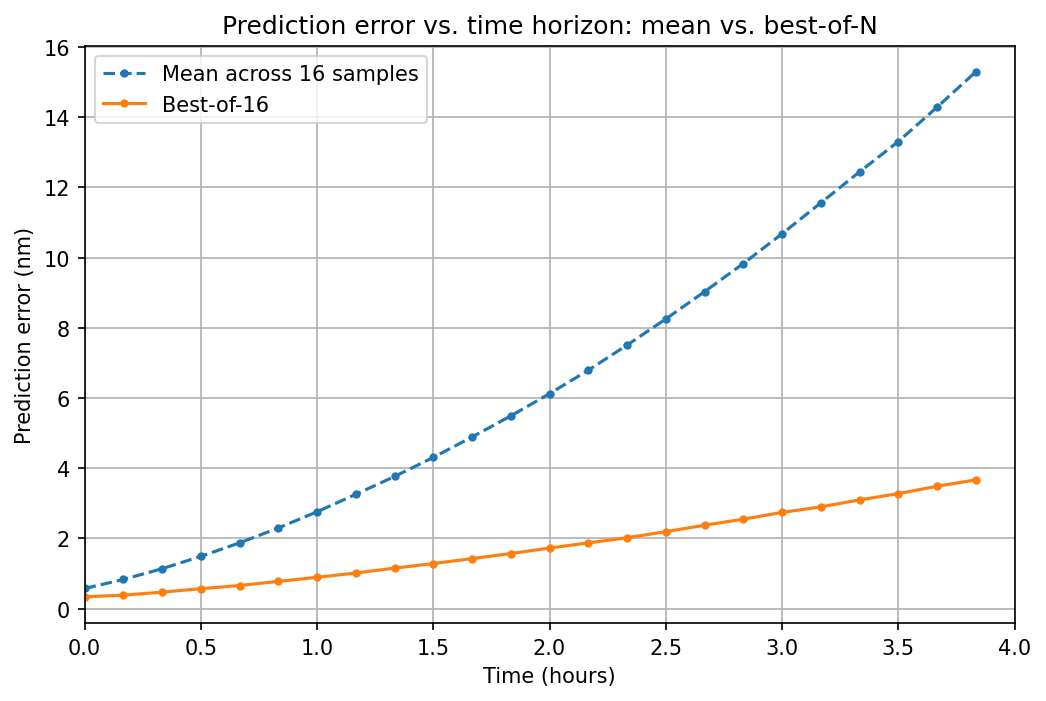

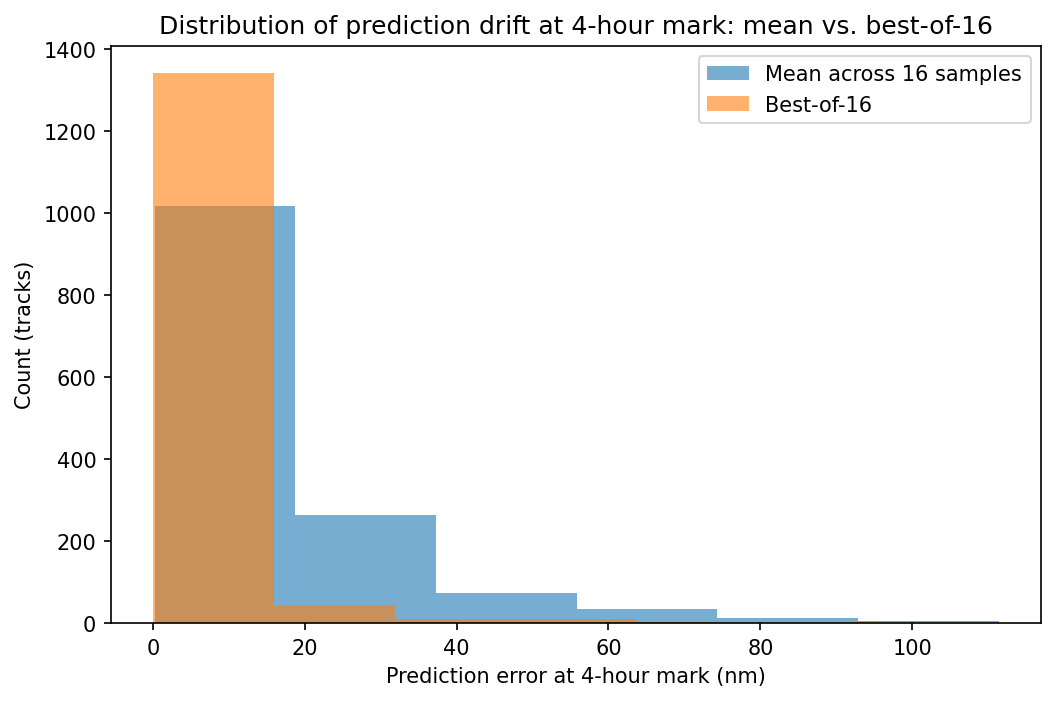

In [16]:
# Check if training was stopped early and note that
pct = 100 * n_tracks_completed / total_tracks
if time_limit_hit:
    print(f"\nPARTIAL RUN: stopped after time limit.")
else:
    print(f"\nFull test set completed.")
print(f"Tracks evaluated: {n_tracks_completed} of {total_tracks} ({pct:.1f}%)")
print(f"Batches evaluated: {n_batches_completed} of {len(aisdls['test'])}")
print(f"Elapsed time: {(time.time() - start_time)/3600:.2f} hours")

# Print some sumary stats
min_errors = torch.cat(l_min_errors, dim=0)
mean_errors = torch.cat(l_mean_errors, dim=0)
masks_all = torch.cat(l_masks, dim=0)

overall_mean = (mean_errors * masks_all).sum().item() / masks_all.sum().item()
overall_min = (min_errors * masks_all).sum().item() / masks_all.sum().item()

print(f"\nMean displacement error (nm): {overall_mean:.3f}")
print(f"Min (best-of-{n_samples_eval}) displacement error (nm): {overall_min:.3f}")
print(f"Average time per sample generation: {sum(sample_times)/len(sample_times):.1f} sec ({len(sample_times)} samples total)")

# Plot 1: mean vs. best-of-N error over time horizon
horizon_hours = np.arange(horizon_len) / 6  # 6 timesteps = 1 hour same as int he paper

min_error_per_step = ((min_errors * masks_all).sum(dim=0) / masks_all.sum(dim=0)).cpu().numpy()
mean_error_per_step = (horizon_error_sum / horizon_mask_sum).numpy()

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(horizon_hours, mean_error_per_step, label=f"Mean across {n_samples_eval} samples", linestyle="--", marker='o', markersize=3)
plt.plot(horizon_hours, min_error_per_step, label=f"Best-of-{n_samples_eval}", marker='o', markersize=3)
plt.xlabel("Time (hours)")
plt.ylabel("Prediction error (nm)")
plt.title("Prediction error vs. time horizon: mean vs. best-of-N")
plt.xlim([0, 4])
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: histogram, mean vs. best-of-N final-step drift (nm) 
final_mask = masks_all[:, -1].bool()
final_mean_per_track = mean_errors[:, -1][final_mask].cpu().numpy()
final_min_per_track = min_errors[:, -1][final_mask].cpu().numpy()

plt.figure(figsize=(8, 5), dpi=150)
plt.hist(final_mean_per_track, bins=6, alpha=0.6, label=f"Mean across {n_samples_eval} samples")
plt.hist(final_min_per_track, bins=6, alpha=0.6, label=f"Best-of-{n_samples_eval}")
plt.xlabel("Prediction error at 4-hour mark (nm)")
plt.ylabel("Count (tracks)")
plt.title(f"Distribution of prediction drift at 4-hour mark: mean vs. best-of-{n_samples_eval}")
plt.legend()
plt.show()

---
# Our Part

## Clean and format our data for the model

*This block will load any files in the CustomData folder and if they dont have a cleaned conunter part in the cleaned folder it will run the cleaning functoin and save it to that folder*

In [17]:
# The folder setup
RAW_DIR = os.path.join(PROJECT_ROOT, "CustomData")
CLEAN_DIR = os.path.join(RAW_DIR, "Cleaned")
os.makedirs(CLEAN_DIR, exist_ok=True)

# The feachures the model needs
requierCols = ["MMSI", "BaseDateTime", "LAT", "LON", "SOG", "COG"]

# The bounds on data based on paper (outside of this we can safy asume there was a mechuirement error)
LatB = (-90.0,90.0)
LonB = (-180.0, 180.0)
SogMax = 30.0
CogB = (0.0, 360.0)
SagNaSentinel = 102.3

def cleanAisCSV(path):
    # load teh file
    df = pd.read_csv(path, usecols=lambda c: c in requierCols)
    nOrg = len(df)

    # drop NAs
    df = df.dropna(subset=requierCols)

    # fix types and formats
    df["MMSI"] = df["MMSI"].astype(int)
    df["BaseDateTime"] = pd.to_datetime( df["BaseDateTime"], errors="coerce")
    df = df.dropna(subset=["BaseDateTime"])
    df["Timestamp"] = (df["BaseDateTime"] - pd.Timestamp("1970-01-01")) // pd.Timedelta(seconds=1)


    for col in ["LAT", "LON", "SOG", "COG"]:
        df[col] = pd.to_numeric(df[col], errors = "coerce")
    df = df.dropna(subset=["LAT", "LON", "SOG", "COG"])

    # Fillter values out of expcted bounds
    df = df[(df["LAT"] >= LatB[0]) & (df["LAT"] <= LatB[1])]
    df = df[(df["LON"] >= LonB[0]) & (df["LON"] <= LonB[1])]
    df = df[(df["SOG"] >= 0) & (df["SOG"] < SagNaSentinel)]
    df = df[df["SOG"] <= SogMax]
    df = df[(df["COG"] >= CogB[0]) & (df["COG"] < CogB[1])]

    df = df.sort_values(["MMSI", "Timestamp"]).reset_index(drop=True)

    nCln = len(df)
    return df, nOrg, nCln

# Look in the data folder and clean the items as needed
rawFile = sorted(f for f in os.listdir(RAW_DIR) if f.lower().endswith(".csv"))
cleanFile = sorted(f for f in os.listdir(CLEAN_DIR) if f.lower().endswith(".csv"))

print(f"Found {len(rawFile)} CSV files in CustomData \n")

for fname in rawFile:
    if fname in cleanFile:
        print(f" - Skipped: {fname}: already exists")
        continue

    srcPath = os.path.join(RAW_DIR, fname)
    dstPath = os.path.join(CLEAN_DIR, fname)

    try:
        df, nOrg, nCln = cleanAisCSV(srcPath)
    except Exception as e:
        # This will just help if the cleaning failed for some resion
        print(f"- Error {fname}: failed to clean: {e}") 
        continue

    df.to_csv(dstPath, index=False)
    nDropped = nOrg - nCln
    pctDropped = 100 * nDropped / nOrg if nOrg else 0
    print(f" - Cleaned {fname}")
    print(f"        {pctDropped:.1f}% dropped from cleaning")

Found 2 CSV files in CustomData 

 - Cleaned AIS_178475344169376017_4155-1784766720628MA.csv
        12.7% dropped from cleaning
 - Cleaned AIS_178486507427276038_10227-1784865075265FL.csv
        21.1% dropped from cleaning


## Load our Data

*Trun the cleaned csv into a plk file to be used by the model*

In [ ]:
# Set up veribales
fileSel = [chosen_idx]       # (only one file at a time you cna change this to change wich is usesd)
resampleMin = 10    # resample so they are every 10 minuts like teh paper
maxGapMins = 2*resampleMin
maxTrackH = 20       # 6 hours for the longest track
minTrackH = 6       # 1 hours for the smallest
maxTrackSteps= int(maxTrackH * 60 / resampleMin)
minTrackSteps= int(minTrackH * 60 / resampleMin)
SOGmax = 30.0
LATres = 0.01
LONres = 0.01
# split settings
TrainFrac, ValFrac, TestFrac = 0.70, 0.15, 0.15
SplitSeed = 24

# Files setups
outDir = os.path.join(PROJECT_DIR, "data", "CustomData")
os.makedirs(outDir, exist_ok=True)

# List every cleaned CSV and pick which one(s) go into THIS dataset
cleanPaths = sorted(glob.glob(os.path.join(CLEAN_DIR, "*.csv")))
cleanNames = [os.path.basename(p) for p in cleanPaths]
print(f"{len(cleanNames)} cleaned files available:")
for i, n in enumerate(cleanNames):
    print(f"  [{i}] {n}")

selPaths = [cleanPaths[i] for i in fileSel]
selNames = [cleanNames[i] for i in fileSel]
print(f"\nUsing {len(selPaths)} file(s): {selNames}")

# load only the selected cleaned CSVs
print(f"Loading {len(selPaths)} selected files...")
dfAll = pd.concat([pd.read_csv(p) for p in selPaths], ignore_index=True)
dfAll = dfAll.sort_values(["MMSI","Timestamp"]).reset_index(drop=True)
print(f"Total loaded: {len(dfAll)} from {dfAll['MMSI'].nunique()} values")

# split the paths when there are big gaps into sub paths
def splitSubPaths(g, maxGapMins):
    gaps = g["Timestamp"].diff().fillna(0)
    voyageID = (gaps > maxGapMins).cumsum()
    return [sub for _, sub in g.groupby(voyageID)]

maxGapSecs = maxGapMins*60
rawVoyage = []
for mmsi, g in dfAll.groupby("MMSI"):
    rawVoyage.extend(splitSubPaths(g, maxGapSecs))
print(f"Split into {len(rawVoyage)} segments from {dfAll['MMSI'].nunique()} vessels")

# Resample each path into 10-minutes
def resamplePaths(g, stepMin):
    g = g.sort_values("Timestamp")
    t0, t1 = g["Timestamp"].iloc[0], g["Timestamp"].iloc[-1]
    stepSec = stepMin * 60
    if t1 <= t0:
        return None
    grid = np.arange(t0, t1 +1, stepSec)
    if len(grid) < 2:
        return None

    lat = np.interp(grid, g["Timestamp"], g["LAT"])
    lon = np.interp(grid, g["Timestamp"], g["LON"])
    sog = np.interp(grid, g["Timestamp"], g["SOG"])

    rad = np.deg2rad(g["COG"].values)
    sini = np.interp(grid, g["Timestamp"], np.sin(rad))
    cosi = np.interp(grid, g["Timestamp"], np.cos(rad))
    cog = (np.rad2deg(np.arctan2(sini, cosi))) % 360

    return pd.DataFrame({"Timestamp": grid, "LAT": lat, "LON": lon, "SOG": sog, "COG": cog})

resampleVoyage = []
MMSIforVoyage = []
for v in rawVoyage:
    mmsi = int(v["MMSI"].iloc[0])
    r = resamplePaths(v, resampleMin)
    if r is not None and len(r) >= minTrackSteps:
        resampleVoyage.append(r)
        MMSIforVoyage.append(mmsi)

print(f"{len(resampleVoyage)} voyages remain after resampling")

# chop longer voyages
finalTracks = []
for mmsi, r in zip(MMSIforVoyage, resampleVoyage):
    n = len(r)
    for start in range(0, n, maxTrackSteps):
        chunk = r.iloc[start:start + maxTrackSteps]
        if len(chunk) >= minTrackSteps:
            finalTracks.append((mmsi, chunk))

# Find ROI for the data -- now only spans whatever's in the selected file(s)
allLat = dfAll["LAT"].values
allLon = dfAll["LON"].values
buffer = 0.05
latMin = np.floor((allLat.min() - buffer) / LATres) * LATres
latMax = np.ceil((allLat.max() + buffer) / LATres) * LATres
lonMin = np.floor((allLon.min() - buffer) / LONres) * LONres
lonMax = np.ceil((allLon.max() + buffer) / LONres) * LONres
LatSzie = int(round((latMax - latMin) / LATres))
LonSzie = int(round((lonMax - lonMin) / LONres))
dateMin = pd.to_datetime(dfAll["Timestamp"], unit="s").min()
dateMax = pd.to_datetime(dfAll["Timestamp"], unit="s").max()


# Normalize the paths [0,1)]
def NormalizeTrack(mmsi, chunk):
    latN = (chunk["LAT"].values - latMin) / (latMax - latMin)
    lonN = (chunk["LON"].values - lonMin) / (lonMax - lonMin)
    sogN = np.clip(chunk["SOG"].values / SOGmax, 0, 1)
    cogN = chunk["COG"].values / 360.0
    ts = chunk["Timestamp"].values
    traj = np.column_stack([latN, lonN, sogN, cogN, ts]).astype(np.float64)
    return {"mmsi": mmsi, "traj": traj}

allData = [NormalizeTrack(mmsi, chunk) for mmsi, chunk in finalTracks]

# Pull random train/test/validatoin splits
rng = np.random.default_rng(SplitSeed)
idx = rng.permutation(len(allData))
nTrain = int(len(idx) * TrainFrac)
nVal = int(len(idx) * ValFrac)

trainData = [allData[i] for i in idx[:nTrain]]
validData = [allData[i] for i in idx[nTrain:nTrain+nVal]]
testData = [allData[i] for i in idx[nTrain + nVal:]]

print(f"Split: train = {len(trainData)}, valid = {len(validData)}, test = {len(testData)}")

# Save as a PKL files -- name reflects which file(s) were used, so different selections don't overwrite each other
Name = "CustemSel" + "-".join(str(i) for i in fileSel)
paths = {
    "train": os.path.join(outDir, f"{Name}_Train.pkl"),
    "valid": os.path.join(outDir, f"{Name}_valid.pkl"),
    "test": os.path.join(outDir, f"{Name}_test.pkl")
}

for name, data, in zip(["train", "valid", "test"], [trainData, validData, testData]):
    with open(paths[name], "wb") as f:
        pickle.dump(data,f)
    print(f"saved {len(data)} tracks as {paths[name]}")

2 cleaned files available:
  [0] AIS_178475344169376017_4155-1784766720628MA.csv
  [1] AIS_178486507427276038_10227-1784865075265FL.csv

Using 1 file(s): ['AIS_178475344169376017_4155-1784766720628MA.csv']
Loading 1 selected files...
Total loaded: 16363178 from 2388 values
Split into 108988 segments from 2388 vessels
14042 voyages remain after resampling
Split: train = 19008, valid = 4073, test = 4074
saved 19008 tracks as C:/Project/TrAISformer\data\CustomData\CustemSel0_Train.pkl
saved 4073 tracks as C:/Project/TrAISformer\data\CustomData\CustemSel0_valid.pkl
saved 4074 tracks as C:/Project/TrAISformer\data\CustomData\CustemSel0_test.pkl


## Train model on OUR data

In [ ]:
# Set up teh files to run on our data 
dataset_name = Name
datadir = "./data/CustomData/"
trainset_name = f"{dataset_name}_Train.pkl"
validset_name = f"{dataset_name}_valid.pkl"
testset_name  = f"{dataset_name}_test.pkl"
lat_size, lon_size = LatSzie, LonSzie
lat_min, lat_max = latMin, latMax
lon_min, lon_max = lonMin, lonMax

# push those values into config_trAISformer.py so trAISformer.py picks them up 
import re

with open(paper_cfg, "r") as f:
    txt = f.read()


txt = re.sub(r'dataset_name = ".*?"', f'dataset_name = "{dataset_name}"', txt)
txt = re.sub(r'if dataset_name == ".*?":', f'if dataset_name == "{dataset_name}":', txt)
txt = re.sub(r'lat_size = \d+', f'lat_size = {lat_size}', txt)
txt = re.sub(r'lon_size = \d+', f'lon_size = {lon_size}', txt)
txt = re.sub(r'lat_min = [\d\.\-]+', f'lat_min = {lat_min}', txt)
txt = re.sub(r'lat_max = [\d\.\-]+', f'lat_max = {lat_max}', txt)
txt = re.sub(r'lon_min = [\d\.\-]+', f'lon_min = {lon_min}', txt)
txt = re.sub(r'lon_max = [\d\.\-]+', f'lon_max = {lon_max}', txt)
txt = re.sub(r'pred_err_v_ranges = \(.*?\)', f'pred_err_v_ranges = ({lat_max - lat_min}, {lon_max - lon_min}, 0, 0)', txt)
txt = re.sub(r'pred_err_lon_min = [\-0-9\.]+', f'pred_err_lon_min = {lon_min}', txt)
txt = re.sub(r'pred_err_horizon_steps = .*', f'pred_err_horizon_steps = {maxTrackSteps - max(int(minTrackSteps/2), 12)}', txt)
txt = re.sub(r'pred_err_fixed_axes = .*', 'pred_err_fixed_axes = False', txt)
txt = re.sub(r'datadir = .*', f'datadir = "{datadir}"', txt)
txt = re.sub(r'trainset_name = .*', f'trainset_name = "{trainset_name}"', txt)
txt = re.sub(r'validset_name = .*', f'validset_name = "{validset_name}"', txt)
txt = re.sub(r'testset_name = .*', f'testset_name = "{testset_name}"', txt)
txt = re.sub(r'init_seqlen = \d+', f'init_seqlen = {max(int(minTrackSteps/2), 12)}', txt)
txt = re.sub(r'max_seqlen = \d+', f'max_seqlen = {maxTrackSteps}', txt)
txt = re.sub(r'min_seqlen = \d+', f'min_seqlen = {minTrackSteps}', txt)

# if n_layers need to be updated adn in mamory (needed later for posable custem architecture)
if 'n_layer' in globals():
    txt = re.sub(r'n_head = \d+', f'n_head = {n_head}', txt)
    txt = re.sub(r'n_layer = \d+', f'n_layer = {n_layer}', txt)
    txt = re.sub(r'n_lat_embd = \d+', f'n_lat_embd = {n_lat_embd}', txt)
    txt = re.sub(r'n_lon_embd = \d+', f'n_lon_embd = {n_lon_embd}', txt)
    txt = re.sub(r'n_sog_embd = \d+', f'n_sog_embd = {n_sog_embd}', txt)
    txt = re.sub(r'n_cog_embd = \d+', f'n_cog_embd = {n_cog_embd}', txt)

with open(custom_cfg, "w") as f:
    f.write(txt)

cf = activate_config(custom_cfg)
print(f"Active config: custom -> '{dataset_name}'.")

# Load our train/valid/test pkls into aisdls (testing loop below needs this)
import datasets, trainers, utils

moving_threshold = 0.05
l_pkl_filenames = [cf.trainset_name, cf.validset_name, cf.testset_name]
Data, aisdatasets, aisdls = {}, {}, {}

for phase, filename in zip(("train", "valid", "test"), l_pkl_filenames):
    datapath = os.path.join(cf.datadir, filename)
    print(f"Loading {datapath}...")
    with open(datapath, "rb") as f:
        l_pred_errors = pickle.load(f)

    for V in l_pred_errors:
        try:
            moving_idx = np.where(V["traj"][:, 2] > moving_threshold)[0][0]
        except IndexError:
            moving_idx = len(V["traj"]) - 1
        V["traj"] = V["traj"][moving_idx:, :]

    Data[phase] = [x for x in l_pred_errors if not np.isnan(x["traj"]).any() and len(x["traj"]) > cf.min_seqlen]
    print(f"  kept {len(Data[phase])} of {len(l_pred_errors)} tracks")

    aisdatasets[phase] = datasets.AISDataset(Data[phase], max_seqlen=cf.max_seqlen + 1, device=cf.device)
    aisdls[phase] = torch.utils.data.DataLoader(aisdatasets[phase], batch_size=cf.batch_size,
                                                 shuffle=(phase != "test"))

print("Ready:", {k: len(v.dataset) for k, v in aisdls.items()})
print(f"Showing the model {max(int(minTrackSteps/2), 12) / 6} Hours")
print(f" Smallest posable track is {minTrackSteps / 6} Hours")

Patched config_trAISformer.py for device auto-detect.
Active config: custom -> 'CustemSel0'.
Loading ./data/CustomData/CustemSel0_Train.pkl...
  kept 8243 of 19008 tracks
Loading ./data/CustomData/CustemSel0_valid.pkl...
  kept 1776 of 4073 tracks
Loading ./data/CustomData/CustemSel0_test.pkl...
  kept 1759 of 4074 tracks
Ready: {'train': 8243, 'valid': 1776, 'test': 1759}


In [ ]:
# Train the model
# On my CPU this can take a long time. set h to the max time you want to let it run
#   (set to a large number if you want it to complet)
h = Our_hour
timeSec = 3600 * h
try: 
    subprocess.run(
        ["python","trAISformer.py"],
        timeout=timeSec
    )
except subprocess.TimeoutExpired:
    print("\n\n --- Training stopped after", h, "hours")

# --- Hit a odd bug here: for Windows there is a 260-character path limit if on windows 
#       make sure your not nested to deep or this block will not realy run (will look like ti ran but 6seconds skipping training) 
#       I do not know the limts for mac or linux

In [21]:
# set up the config object
cf = activate_config(custom_cfg)
cf.retrain = False

model = models.TrAISformer(cf, partition_model=None) # biuld model architecture
model.load_state_dict(torch.load(cf.ckpt_path)) # load pre-trained wieghts into model
model = model.to(cf.device) # move model on to device (CPU or GPU)

Patched config_trAISformer.py for device auto-detect.


## Test on OUR data

In [ ]:
# Set up
h = Our_hour            # how long to let the model run in hours
timeSec = 3600 * h  # that time converted to seconds
init_seqlen = cf.init_seqlen
horizon_len = cf.max_seqlen - init_seqlen 
hours = horizon_len / 6
max_seqlen = init_seqlen + horizon_len
n_samples_eval = 16 # how many atempts at the path that the model gets payper uses 16 lower for faster testing

# set up varubles tracking not settings
start_time = time.time()
n_tracks_completed = 0
n_batches_completed = 0
time_limit_hit = False 
total_tracks = len(aisdls["test"].dataset)
model.eval()
l_min_errors, l_mean_errors, l_masks = [], [], []
horizon_error_sum = torch.zeros(horizon_len)
horizon_mask_sum = torch.zeros(horizon_len)
final_step_errors = []
sample_times = []

# Undo normalization (uses stored ROI in model, not hard coded ROIs from paper)
v_ranges = torch.tensor([model.lat_range, model.lon_range, model.sog_range, 360.0]).to(cf.device)
v_roi_min = torch.tensor([model.lat_min, model.lon_min, 0.0, 0.0]).to(cf.device)

pbar = tqdm(enumerate(aisdls["test"]), total=len(aisdls["test"]))

with torch.no_grad():
    for it, (seqs, masks, seqlens, mmsis, time_starts) in pbar:
        elapsedT = time.time() - start_time
        if elapsedT > timeSec:  # check if time limt is hit
            time_limit_hit = True
            print("\n\n --- Testing stopped after", h, "hours")
            break

        seqs_init = seqs[:, :init_seqlen, :].to(cf.device)
        masks_b = masks[:, :max_seqlen].to(cf.device)
        batchsize = seqs.shape[0]
        error_ens = torch.zeros((batchsize, horizon_len, n_samples_eval)).to(cf.device)

        for i_sample in range(n_samples_eval):
            t0 = time.time()
            preds = trainers.sample(model, seqs_init, max_seqlen - init_seqlen,
                                     temperature=1.0, sample=True,
                                     sample_mode=cf.sample_mode,
                                     r_vicinity=cf.r_vicinity, top_k=cf.top_k)
            t1 = time.time()
            sample_times.append(t1 - t0)
            tqdm.write(f"Batch {it+1}/{len(aisdls['test'])}, sample {i_sample+1}/{n_samples_eval}: {t1-t0:.1f} sec")

            inputs = seqs[:, :max_seqlen, :].to(cf.device)
            input_coords = (inputs * v_ranges + v_roi_min) * torch.pi / 180
            pred_coords = (preds * v_ranges + v_roi_min) * torch.pi / 180
            d = utils.haversine(input_coords, pred_coords) * masks_b
            error_ens[:, :, i_sample] = d[:, cf.init_seqlen:]

        batch_mean_over_samples = error_ens.mean(dim=-1)
        batch_mask = masks_b[:, cf.init_seqlen:]
        horizon_error_sum += (batch_mean_over_samples * batch_mask).sum(dim=0).cpu()
        horizon_mask_sum += batch_mask.sum(dim=0).cpu()

        final_mask = batch_mask[:, -1].bool()
        final_errors_this_batch = error_ens[:, -1, :][final_mask]
        final_step_errors.append(final_errors_this_batch.flatten().cpu())

        l_min_errors.append(error_ens.min(dim=-1).values)
        l_mean_errors.append(batch_mean_over_samples)
        l_masks.append(batch_mask)

        n_tracks_completed += batchsize
        n_batches_completed += 1

  0%|          | 0/55 [00:06<?, ?it/s]

Batch 1/55, sample 1/16: 6.6 sec


  0%|          | 0/55 [00:13<?, ?it/s]

Batch 1/55, sample 2/16: 6.5 sec


  0%|          | 0/55 [00:19<?, ?it/s]

...

Batch 55/55, sample 14/16: 6.7 sec


 98%|█████████▊| 54/55 [2:03:55<01:54, 114.24s/it]

Batch 55/55, sample 15/16: 6.7 sec


100%|██████████| 55/55 [2:04:01<00:00, 135.31s/it]

Batch 55/55, sample 16/16: 6.7 sec


## Plots of the area, paths, error, and training


Full test set completed.
Tracks evaluated: 1759 of 1759 (100.0%)
Batches evaluated: 55 of 55
Elapsed time: 2.07 hours

Mean displacement error (nm): 17.739
Min (best-of-16) displacement error (nm): 5.259
Average time per sample generation: 8.4 sec (880 samples total)


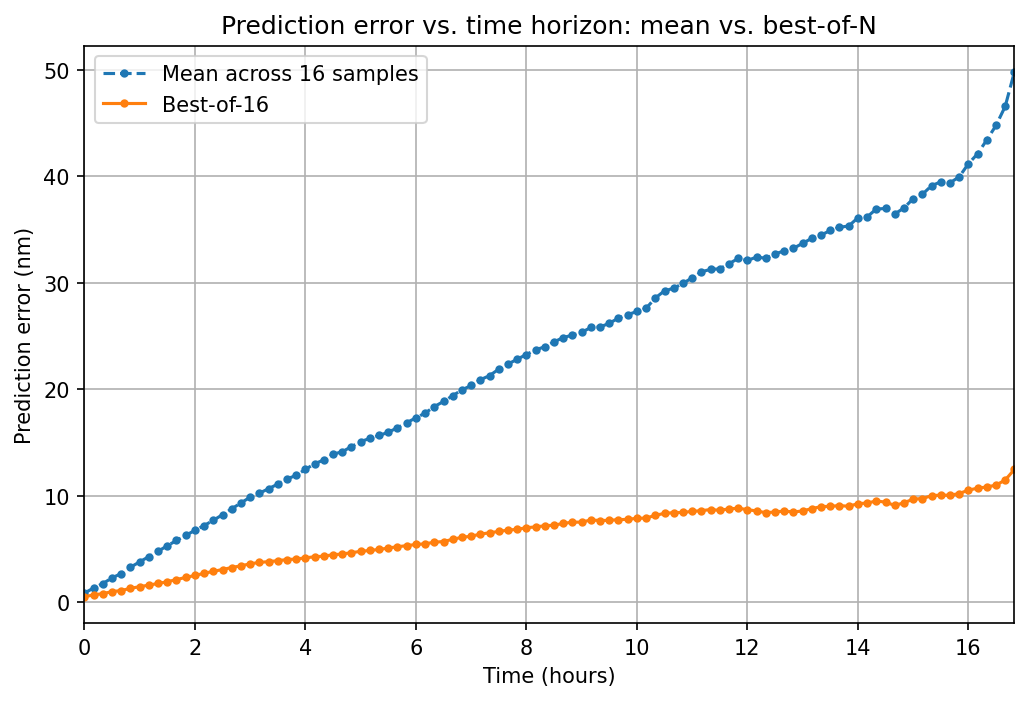

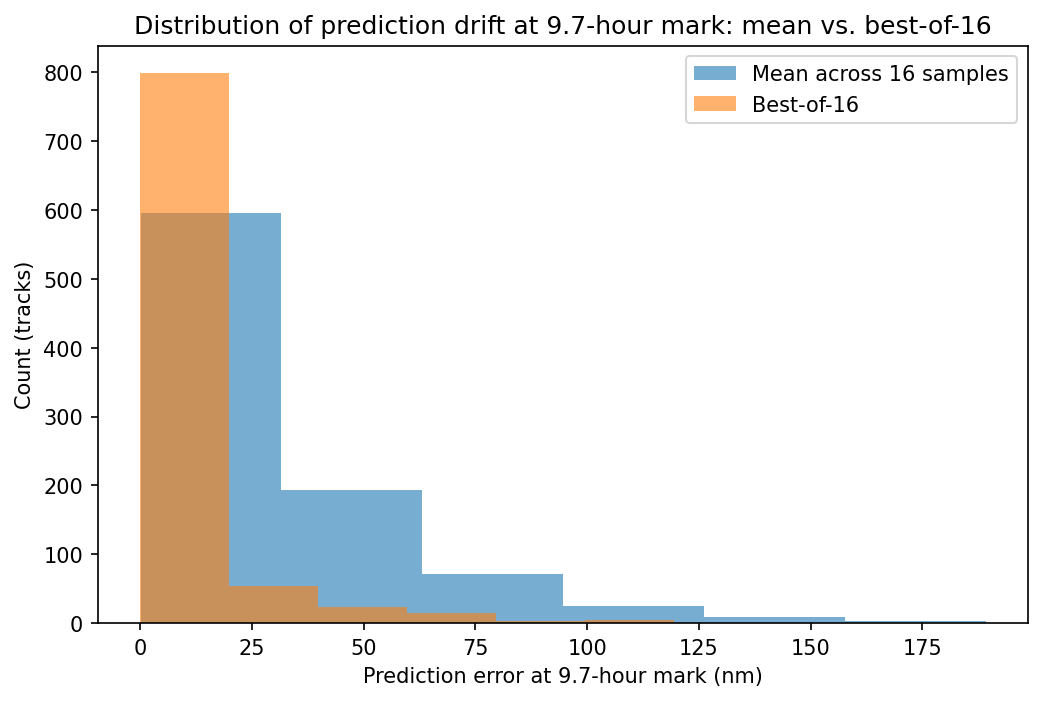

In [23]:
# CHeck if training was stopped early and note that
pct = 100 * n_tracks_completed / total_tracks
if time_limit_hit:
    print(f"\nPARTIAL RUN: stopped after time limit.")
else:
    print(f"\nFull test set completed.")
print(f"Tracks evaluated: {n_tracks_completed} of {total_tracks} ({pct:.1f}%)")
print(f"Batches evaluated: {n_batches_completed} of {len(aisdls['test'])}")
print(f"Elapsed time: {(time.time() - start_time)/3600:.2f} hours")

# Print some sumary stats
min_errors = torch.cat(l_min_errors, dim=0)
mean_errors = torch.cat(l_mean_errors, dim=0)
masks_all = torch.cat(l_masks, dim=0)

overall_mean = (mean_errors * masks_all).sum().item() / masks_all.sum().item()
overall_min = (min_errors * masks_all).sum().item() / masks_all.sum().item()

print(f"\nMean displacement error (nm): {overall_mean:.3f}")
print(f"Min (best-of-{n_samples_eval}) displacement error (nm): {overall_min:.3f}")
print(f"Average time per sample generation: {sum(sample_times)/len(sample_times):.1f} sec ({len(sample_times)} samples total)")

# Plot 1: mean vs. best-of-N error over time horizon
horizon_hours = np.arange(horizon_len) / 6  # 6 timesteps = 1 hour same as paper

min_error_per_step = ((min_errors * masks_all).sum(dim=0) / masks_all.sum(dim=0)).cpu().numpy()
mean_error_per_step = (horizon_error_sum / horizon_mask_sum).numpy()

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(horizon_hours, mean_error_per_step, label=f"Mean across {n_samples_eval} samples", linestyle="--", marker='o', markersize=3)
plt.plot(horizon_hours, min_error_per_step, label=f"Best-of-{n_samples_eval}", marker='o', markersize=3)
plt.xlabel("Time (hours)")
plt.ylabel("Prediction error (nm)")
plt.title("Prediction error vs. time horizon: mean vs. best-of-N")
plt.xlim([0, horizon_hours[-1]])
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: histogram, mean vs. best-of-N final-step drift (nm) 

min_coverage = 0.5   # require at least half of this run's tracks to still be valid at that step
coverage_ok = (horizon_mask_sum >= min_coverage * n_tracks_completed).nonzero()
final_step = int(coverage_ok.max()) if len(coverage_ok) > 0 else int(horizon_mask_sum.nonzero().max())
final_step_hours = horizon_hours[final_step]


final_mask = masks_all[:, final_step].bool()
final_mean_per_track = mean_errors[:, final_step][final_mask].cpu().numpy()
final_min_per_track = min_errors[:, final_step][final_mask].cpu().numpy()

plt.figure(figsize=(8, 5), dpi=150)
plt.hist(final_mean_per_track, bins=6, alpha=0.6, label=f"Mean across {n_samples_eval} samples")
plt.hist(final_min_per_track, bins=6, alpha=0.6, label=f"Best-of-{n_samples_eval}")
plt.xlabel(f"Prediction error at {final_step_hours:.2g}-hour mark (nm)")
plt.ylabel("Count (tracks)")
plt.title(f"Distribution of prediction drift at {final_step_hours:.2g}-hour mark: mean vs. best-of-{n_samples_eval}")
plt.legend()
plt.show()

Reading saved training outputs from: ./results/CustemSel0-pos-pos_vicinity-10-40-blur-True-False-2-1.0-data_size-514-918-30-72-embd_size-256-256-128-128-head-8-8-bs-32-lr-0.0006-seqlen-18-120/
Found 50 epoch snapshot images.


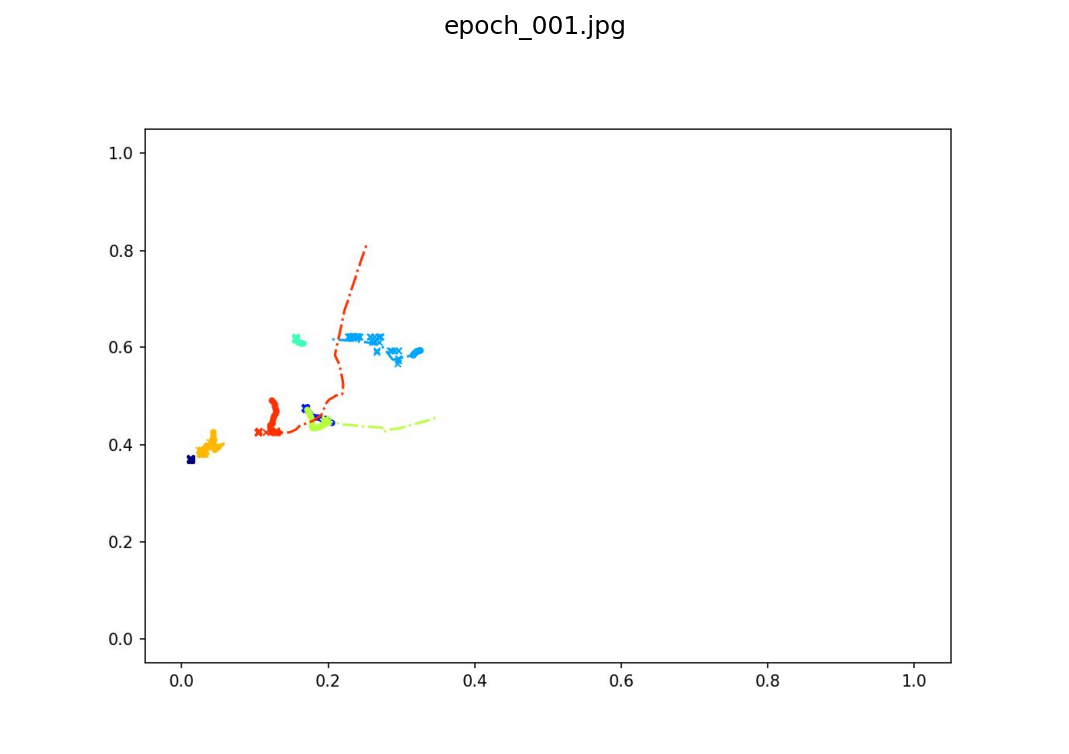

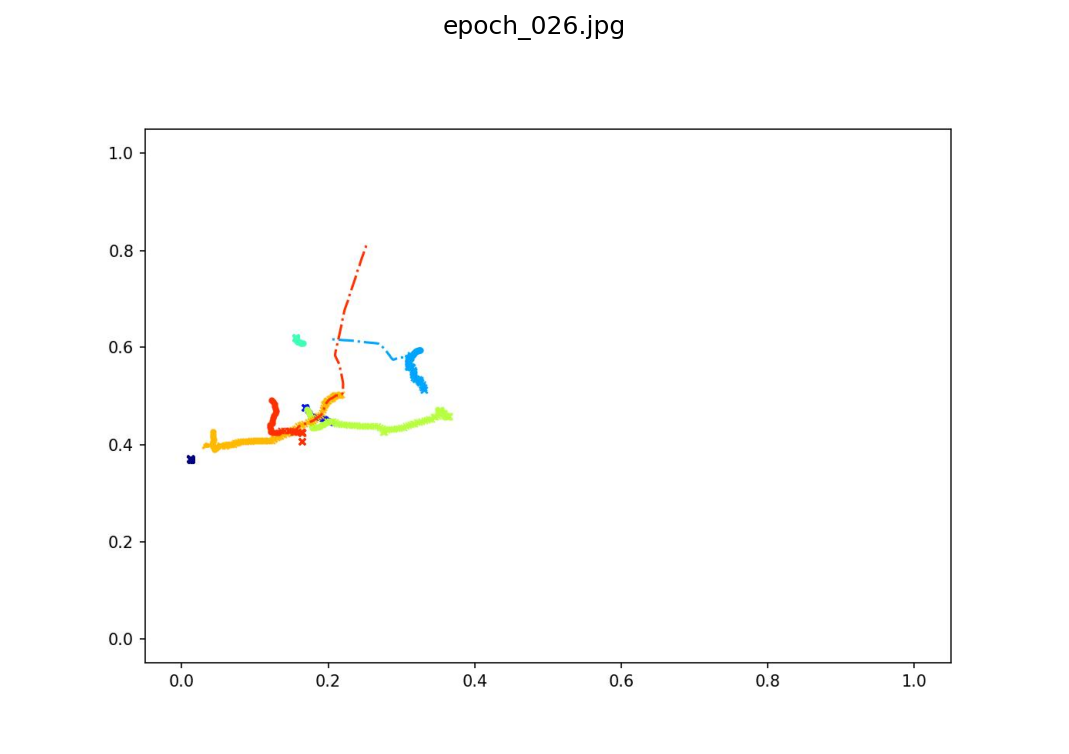

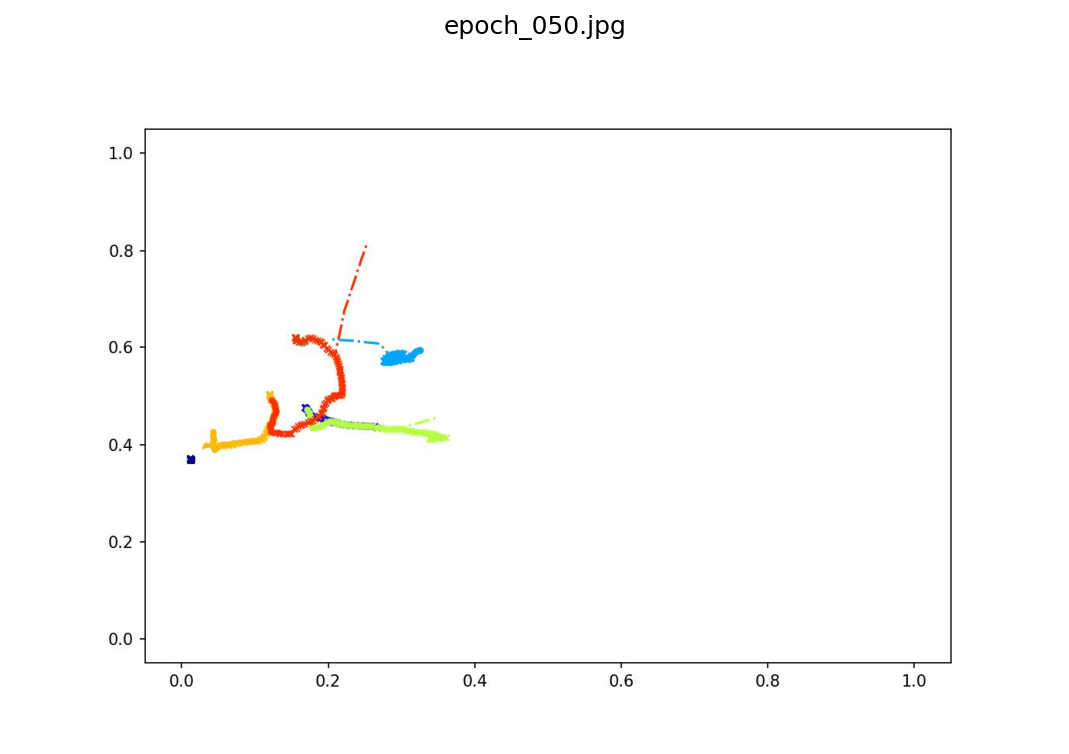

No prediction_error.png found for this run.


In [24]:
# Pull the plots trAISformer.py/trainers.py made

run_dir = cf.savedir
print("Reading saved training outputs from:", run_dir)

# Trajectory snapshots, every 3 epoches
epoch_imgs = sorted(glob.glob(os.path.join(run_dir, "epoch_*.jpg")))
print(f"Found {len(epoch_imgs)} epoch snapshot images.")

show_idx = sorted(set([0, len(epoch_imgs) // 2, len(epoch_imgs) - 1]))
for i in show_idx:
    img = plt.imread(epoch_imgs[i])
    plt.figure(figsize=(9, 6), dpi=150)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(epoch_imgs[i]))
    plt.show()

# The paper's final min-error-vs-horizon plot
pred_err_path = os.path.join(run_dir, "prediction_error.png")
if os.path.exists(pred_err_path):
    img = plt.imread(pred_err_path)
    plt.figure(figsize=(9, 6), dpi=150)
    plt.imshow(img)
    plt.axis("off")
    plt.title("prediction_error.png")
    plt.show()
else:
    print("No prediction_error.png found for this run.")


Reading loss history from: ./results/CustemSel0-pos-pos_vicinity-10-40-blur-True-False-2-1.0-data_size-514-918-30-72-embd_size-256-256-128-128-head-8-8-bs-32-lr-0.0006-seqlen-18-120\log_2026-08-18-19-17-29_SpectrumEngine_log.log


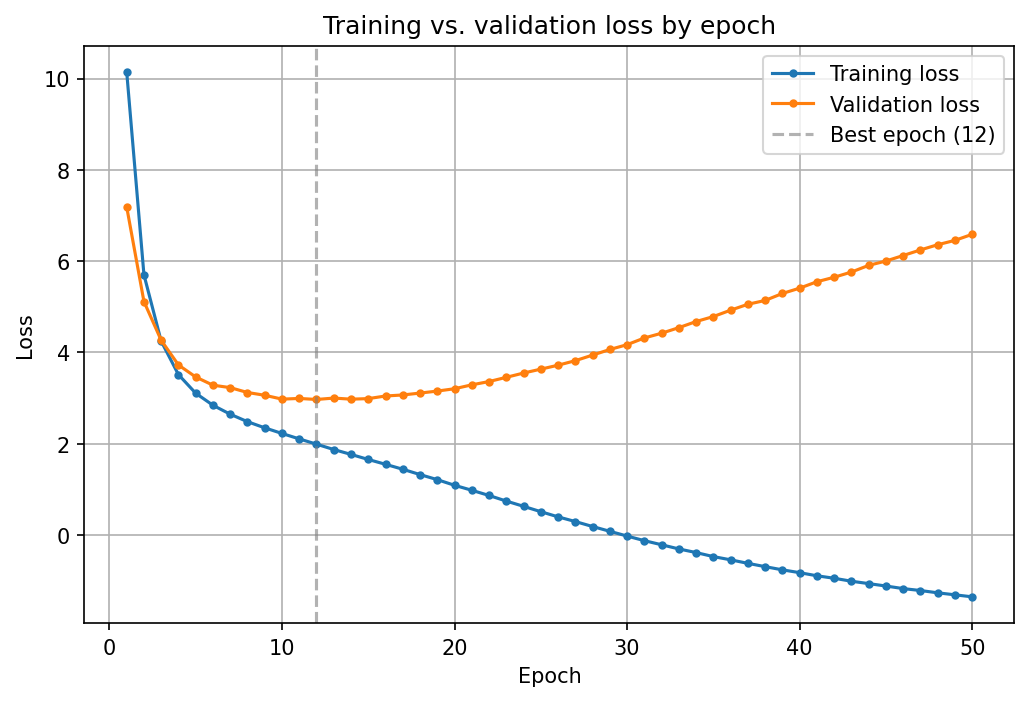

In [25]:
# plot training / validatoin loss by epoch over training time
import re

log_files = sorted(glob.glob(os.path.join(run_dir, "log_*.log")), key=os.path.getmtime)
log_path = log_files[-1]   # most recent run's log
print("Reading loss history from:", log_path)

train_loss, valid_loss = {}, {}
with open(log_path, "r") as f:
    for line in f:
        m = re.search(r"Training, epoch (\d+), loss ([\-0-9\.]+),", line)
        if m:
            train_loss[int(m.group(1))] = float(m.group(2))
        m = re.search(r"Valid, epoch (\d+), loss ([\-0-9\.]+)\.", line)
        if m:
            valid_loss[int(m.group(1))] = float(m.group(2))

epochs = sorted(train_loss)
best_epoch = min(valid_loss, key=valid_loss.get)

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(epochs, [train_loss[e] for e in epochs], label="Training loss", marker='o', markersize=3)
plt.plot(epochs, [valid_loss[e] for e in epochs], label="Validation loss", marker='o', markersize=3)
plt.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. validation loss by epoch")
plt.grid(True)
plt.legend()
plt.show()


Found 1079 paths
Using 0th index


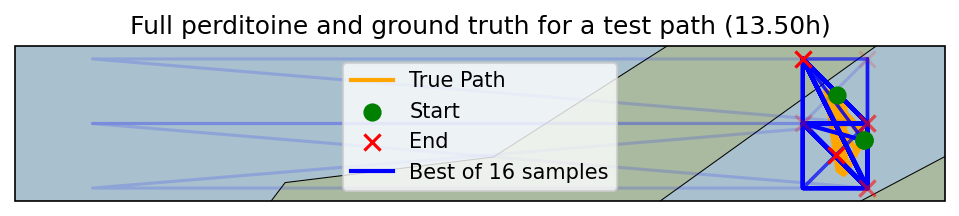

Found 1079 paths
Using 1th index


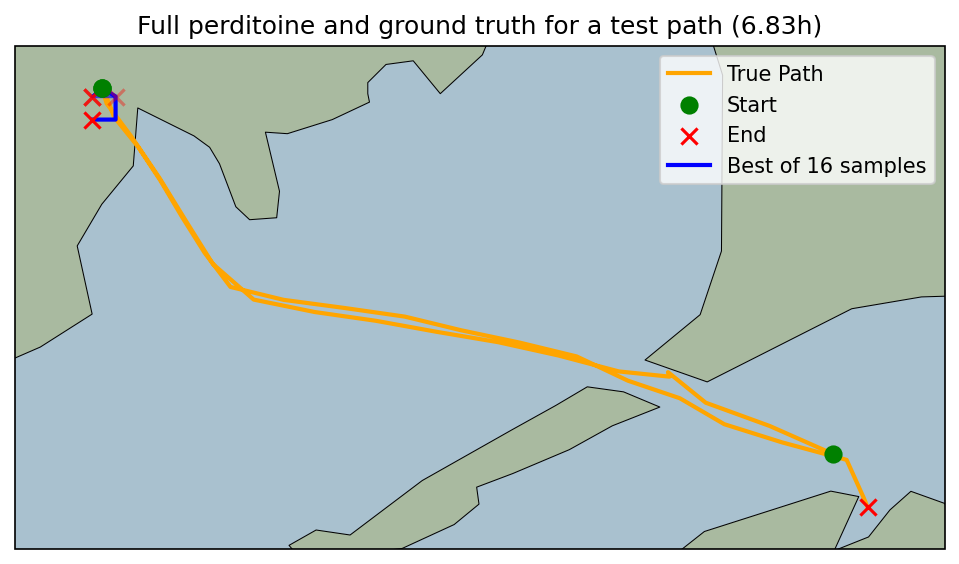

Found 1079 paths
Using 2th index


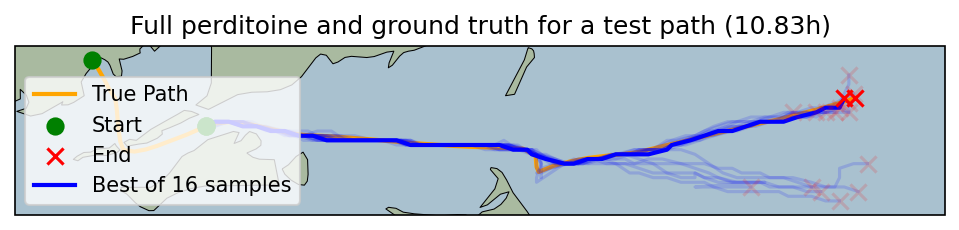

Found 1079 paths
Using 3th index


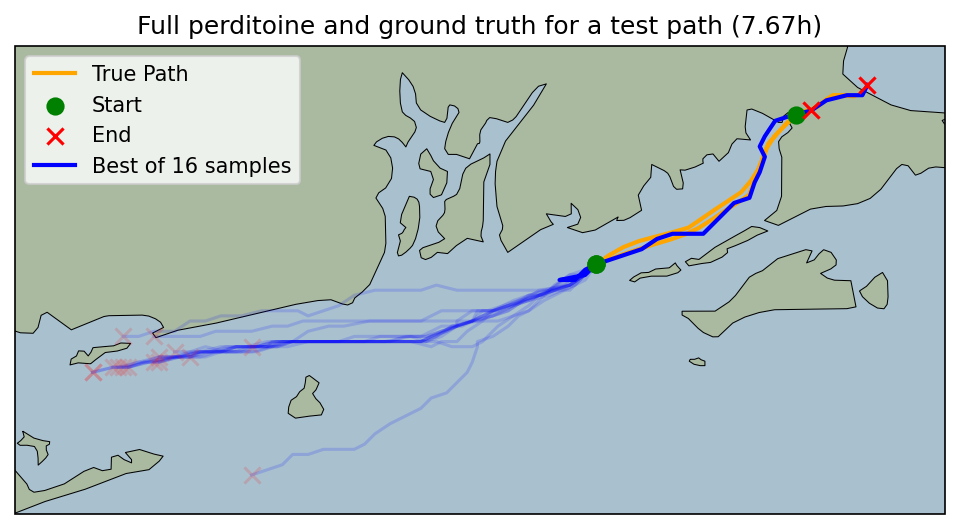

Found 1079 paths
Using 4th index


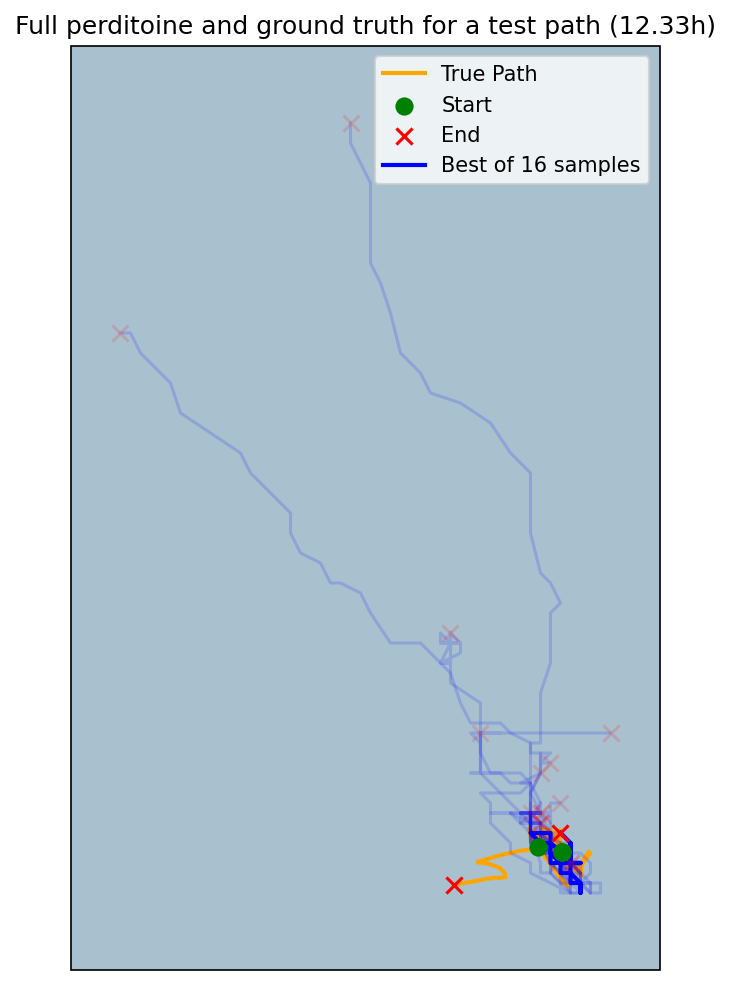

Found 1079 paths
Using 5th index


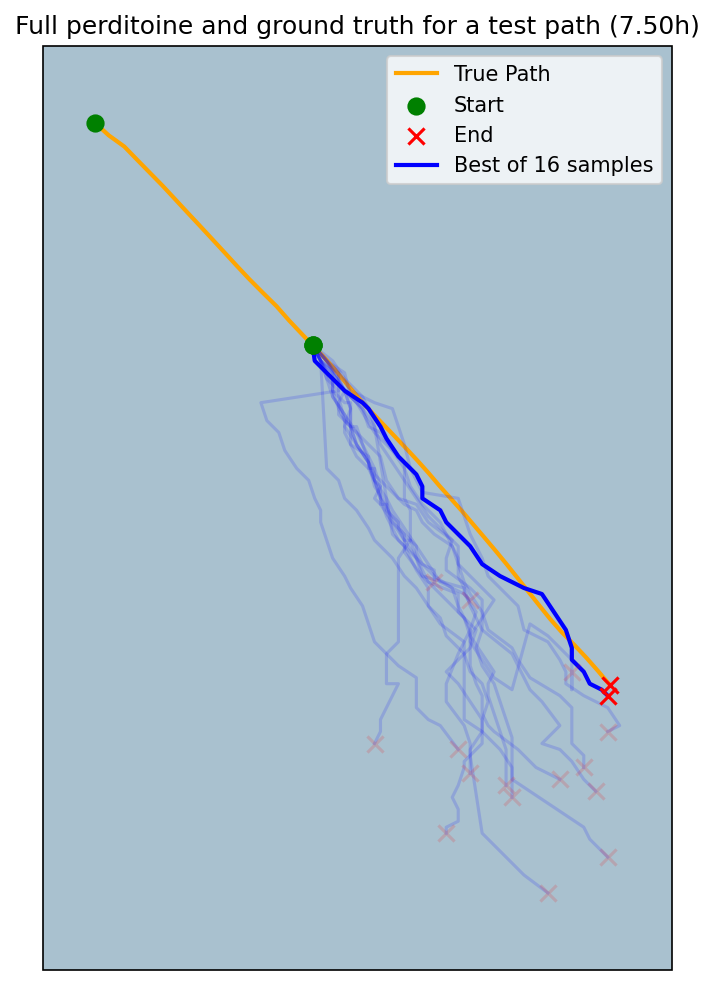

Found 1079 paths
Using 6th index


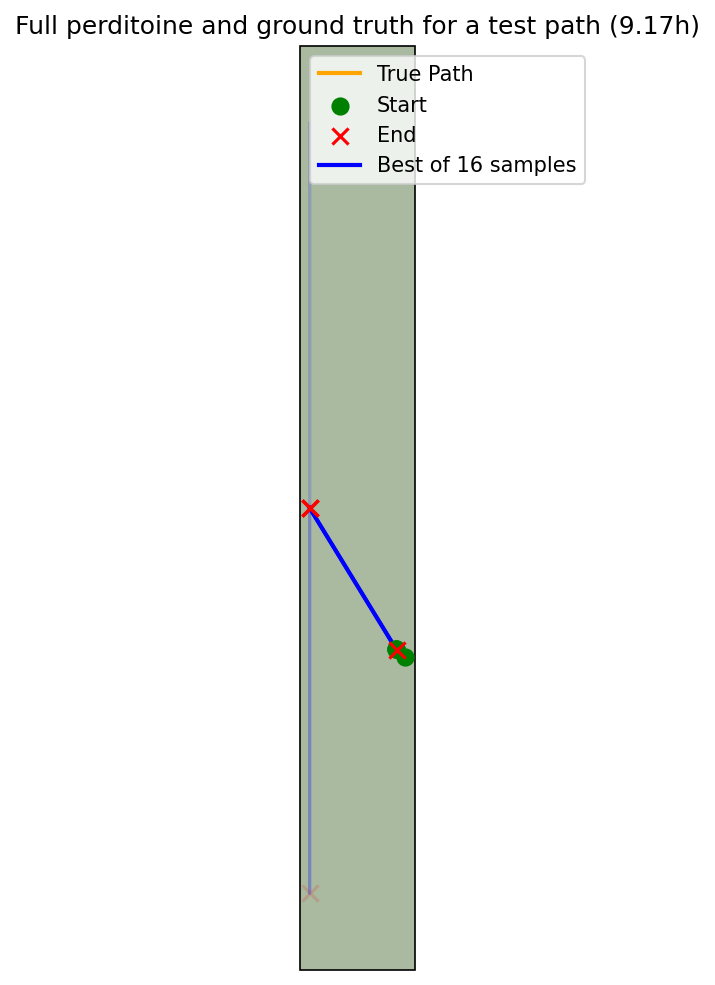

Found 1079 paths
Using 7th index


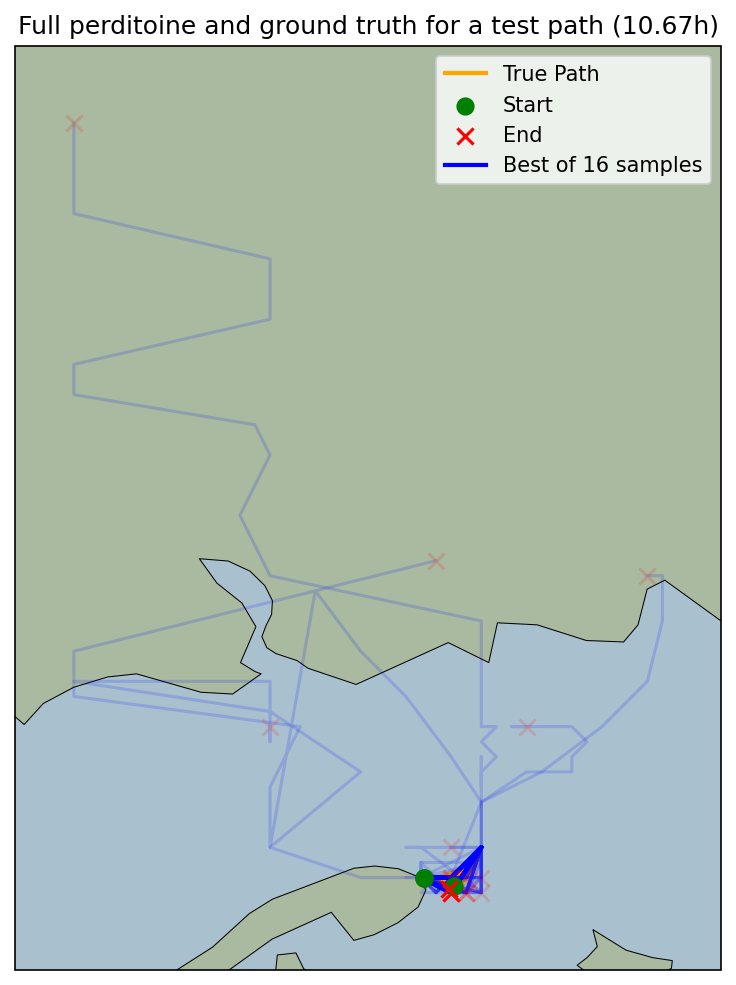

Found 1079 paths
Using 8th index


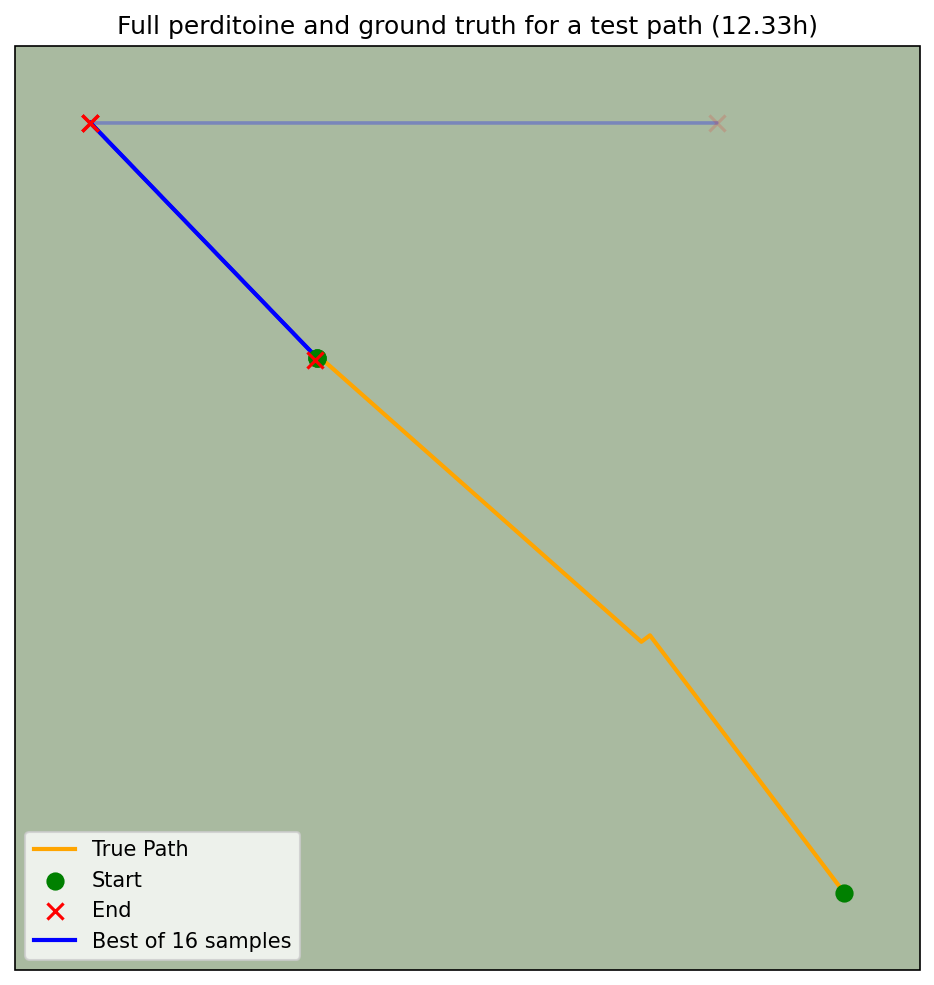

Found 1079 paths
Using 9th index


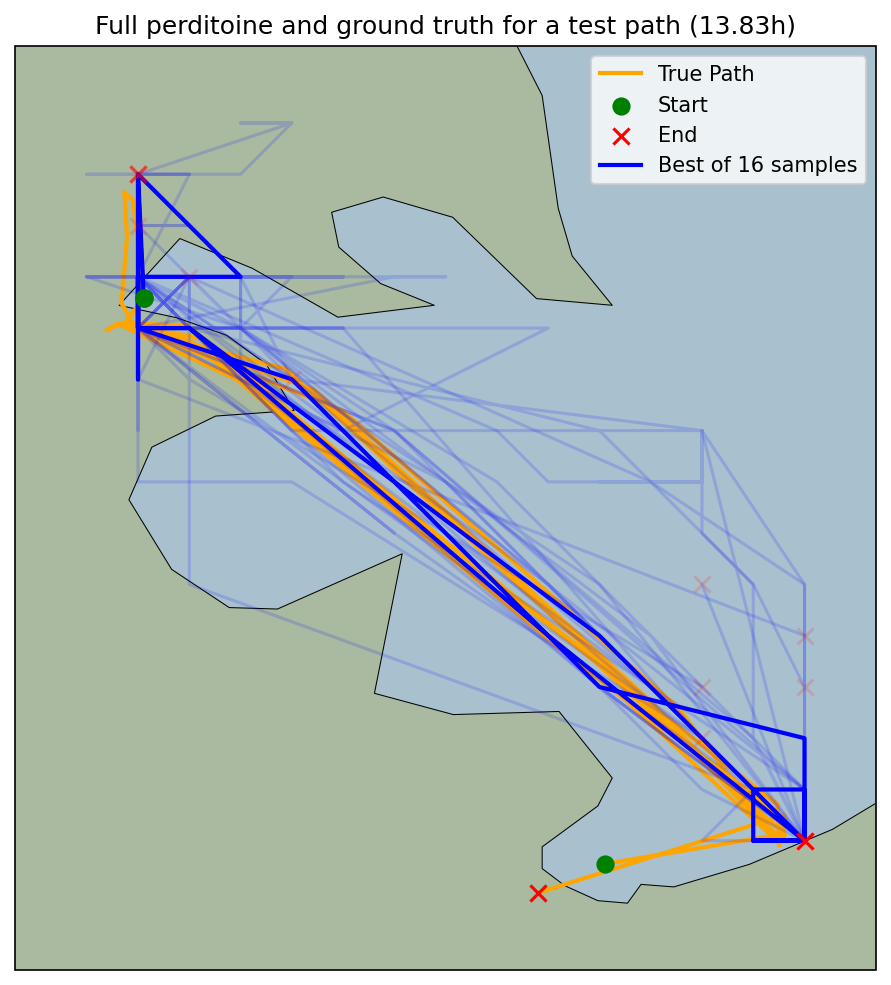

Found 1079 paths
Using 10th index


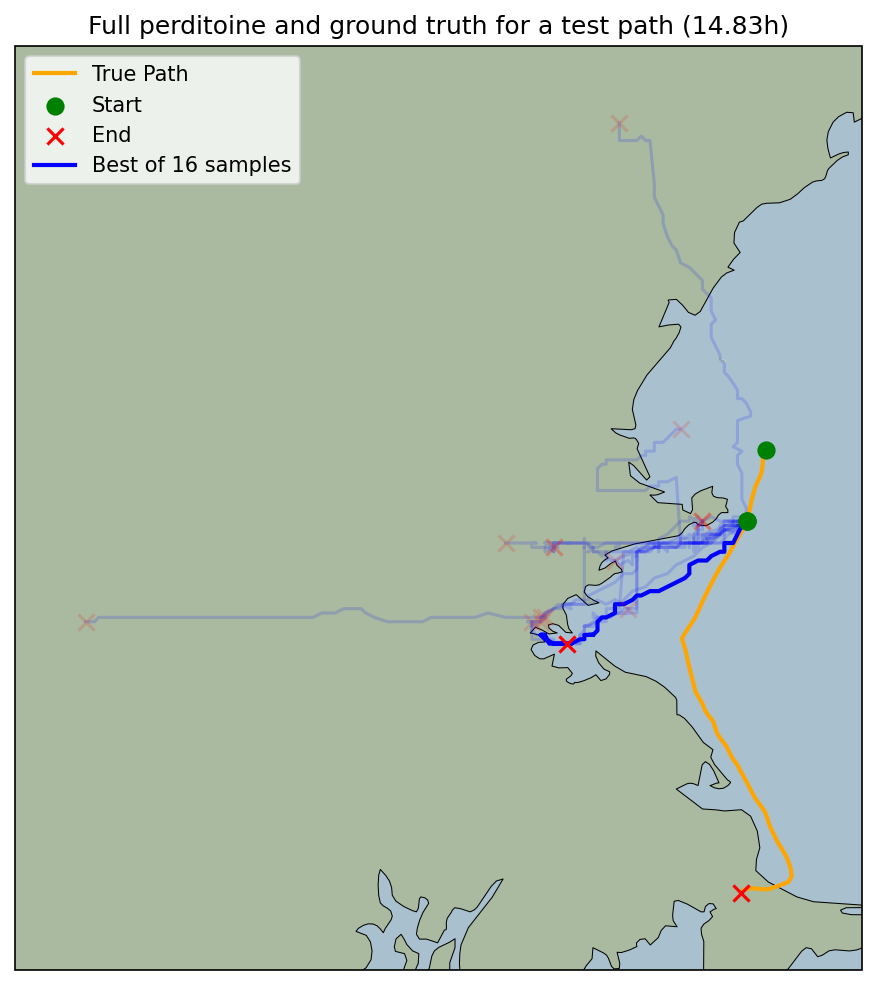

Found 1079 paths
Using 11th index


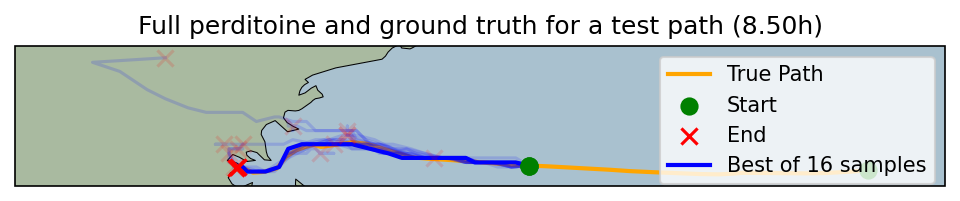

Found 1079 paths
Using 12th index


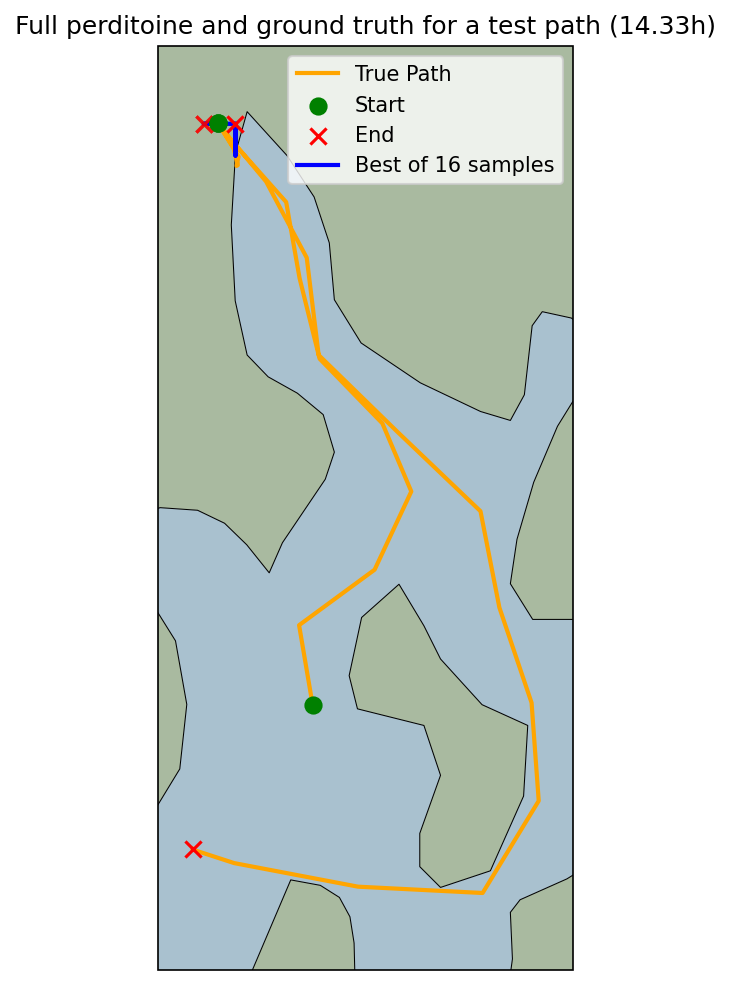

Found 1079 paths
Using 13th index


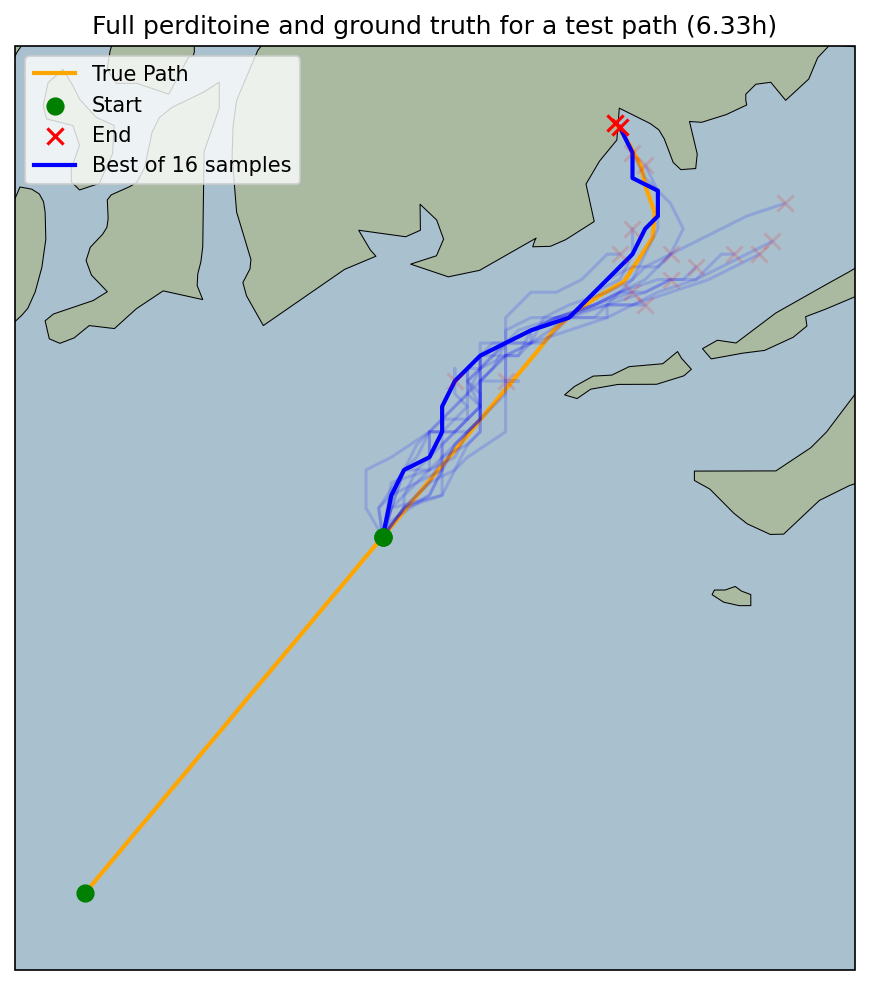

Found 1079 paths
Using 14th index


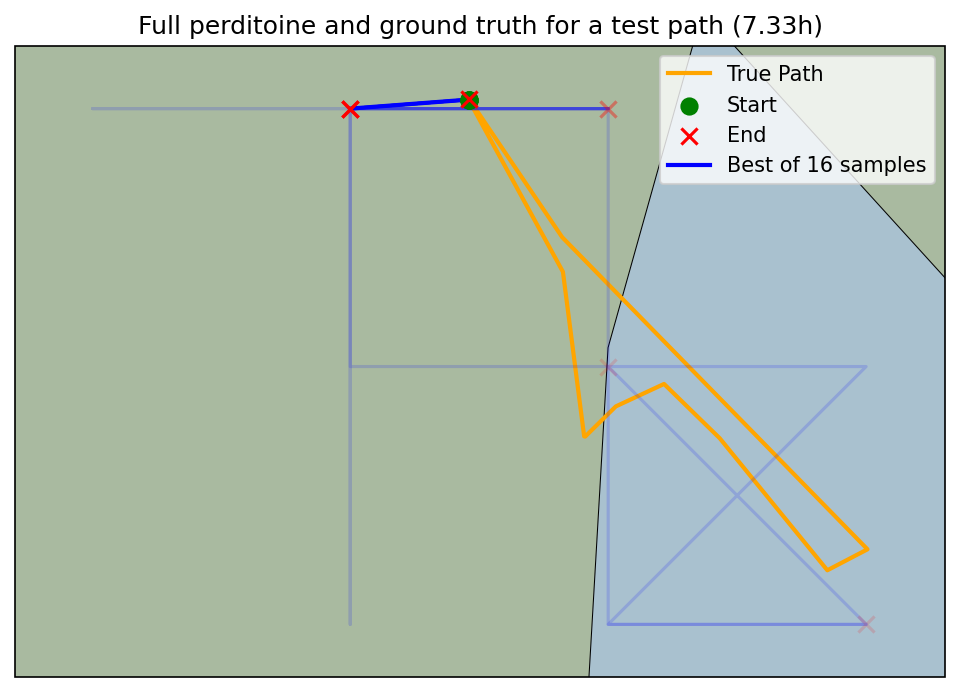

Found 1079 paths
Using 15th index


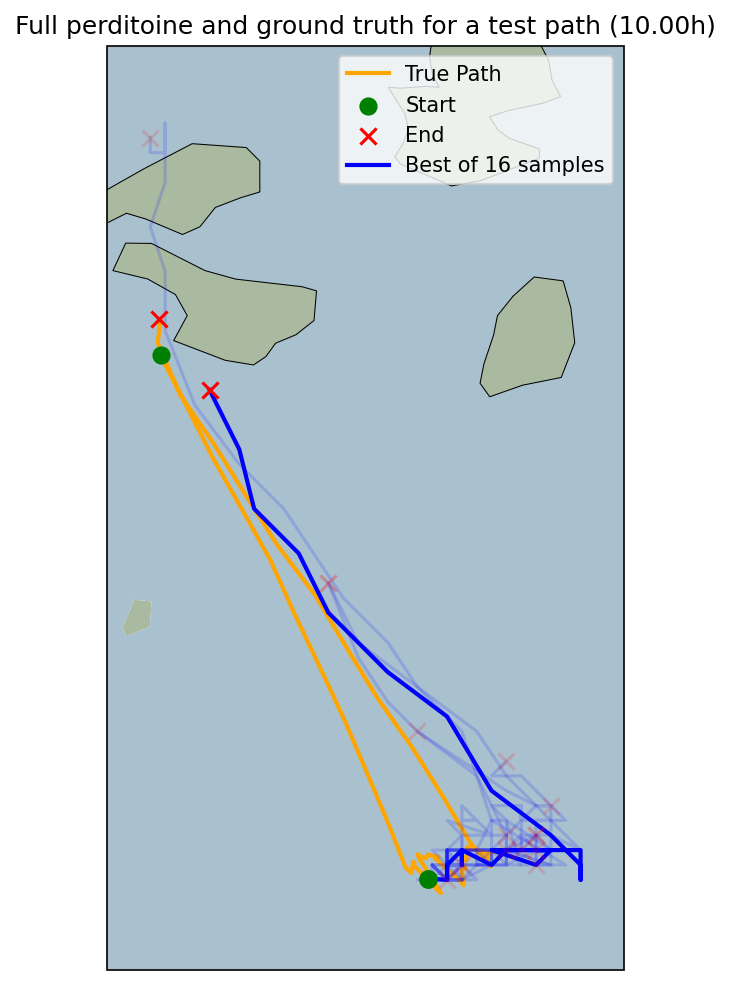

Found 1079 paths
Using 16th index


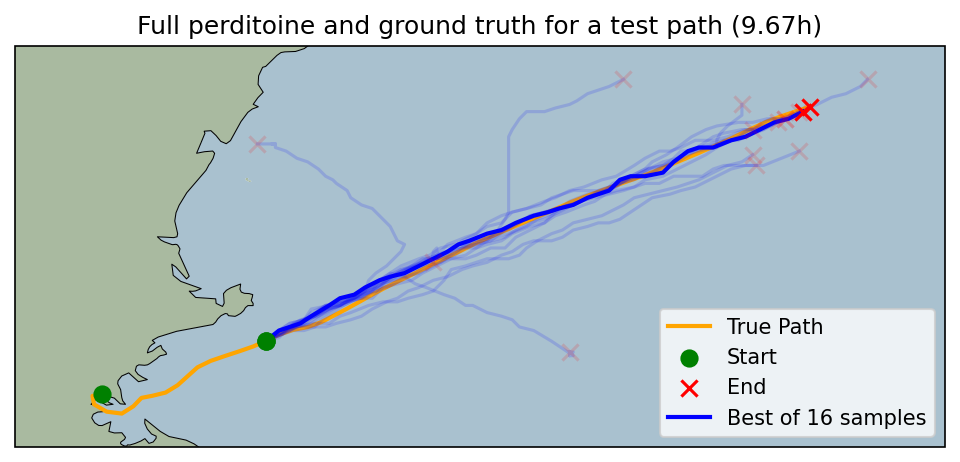

Found 1079 paths
Using 17th index


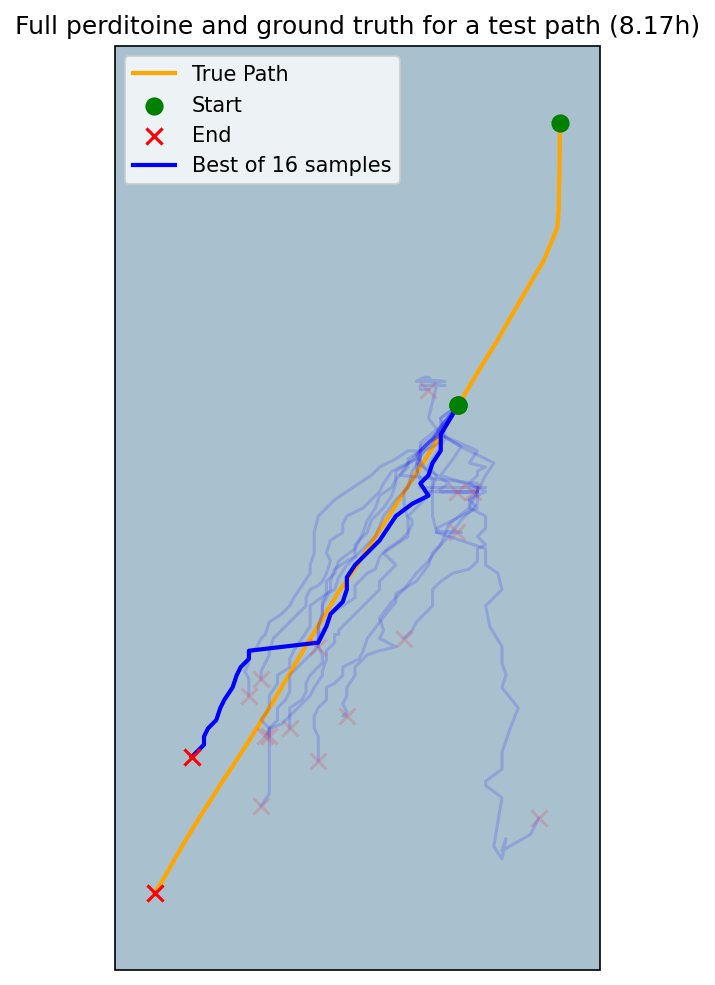

Found 1079 paths
Using 18th index


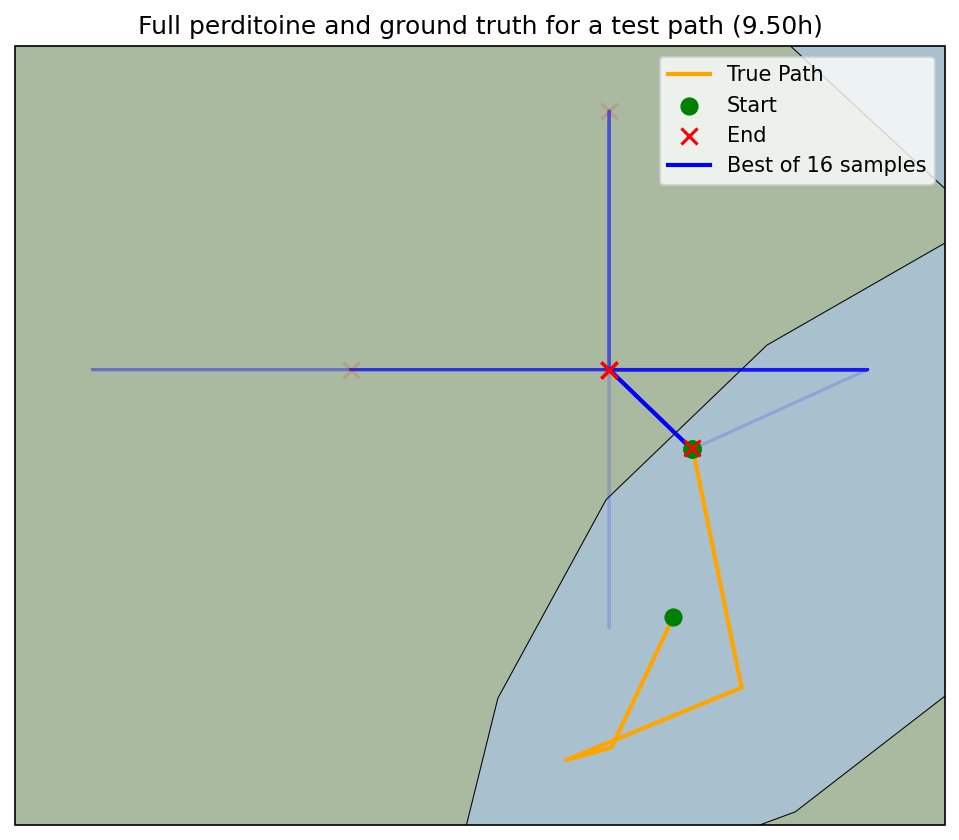

Found 1079 paths
Using 19th index


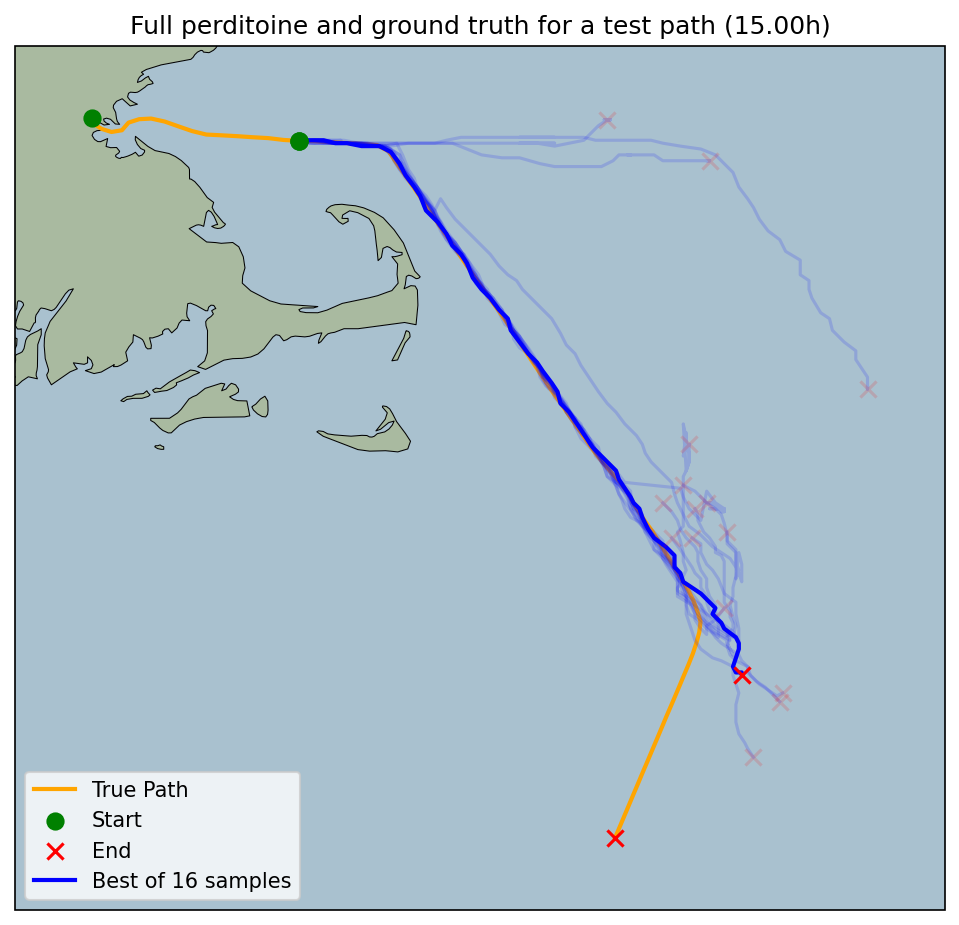

In [ ]:
# Vis the path and perdicted
def makePathPlot(idx=0,hour=20,tol=2,samp=16, iPlot = -1):
    def toLatLong(normTraj):
        lat = normTraj[..., 0] * model.lat_range + model.lat_min
        lon = normTraj[..., 1] * model.lon_range + model.lon_min
        return lat, lon

    # get tracks that match legth
    tracks = [
        i for i, v in enumerate(Data["test"])
        if abs(len(v["traj"])* resampleMin / 60 - hour) <= tol
    ]
    print(f"Found {len(tracks)} paths")
    if iPlot != -1:
        print(f"Using {idx}th index")
    else:
        print(f"Using {idx}th index for the {iPlot}th plot")
    # pull one track based on teh idx
    track = tracks[idx]
    v = Data["test"][track]

    seq = torch.tensor(v["traj"][:,:4], dtype=torch.float32).unsqueeze(0).to(cf.device)
    seqInt = seq[:, :cf.init_seqlen, :]
    fullLen = seq.shape[1]
    horizonLen = fullLen - cf.init_seqlen

    Vrange = torch.tensor([model.lat_range, model.lon_range, model.sog_range, 360.0]).to(cf.device)
    VroiMin = torch.tensor([model.lat_min, model.lon_min, 0.0, 0.0]).to(cf.device)

    model.eval()
    allPerds = []
    with torch.no_grad():
        for _ in range(samp):
            preds = trainers.sample(model, seqInt, horizonLen, temperature=1.0, sample=True, 
                                    sample_mode=cf.sample_mode, r_vicinity=cf.r_vicinity, top_k=cf.top_k)
            allPerds.append(preds)

    trueLat, trueLon = toLatLong(seq[0].cpu())

    predPath, errors = [], []
    for preds in allPerds:
        lat, lon = toLatLong(preds[0].cpu())
        predPath.append((lat,lon))
        inputCords = (seq * Vrange + VroiMin) * torch.pi / 180
        predCords = (preds * Vrange + VroiMin) * torch.pi / 180
        d = utils.haversine(inputCords, predCords)[0, cf.init_seqlen:]
        errors.append(d.mean().item())

    # Get the best path
    best_i = int(np.argmin(errors))


    # =============================
    # Plot the resalts of the paths
    plt.figure(figsize=(8,8), dpi=150)
    # add a costline under the plots
    ax = plt.axes(projection=ccrs.PlateCarree()) 
    land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor="#a9baa0")
    ocean_10m = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', facecolor="#a9c1cf")
    coast_10m = cfeature.NaturalEarthFeature('physical', 'coastline', '10m', facecolor='none', edgecolor='black', linewidth=0.5)
    ax.add_feature(land_10m, zorder=0)
    ax.add_feature(ocean_10m, zorder=0)
    ax.add_feature(coast_10m, zorder=1)


    # get the right area of the cost
    allLats = torch.cat([trueLat] + [lat for lat, lon in predPath])
    allLons = torch.cat([trueLon] + [lon for lat, lon in predPath])
    rangLat = allLats.max() - allLats.min()
    rangLong = allLons.max() - allLons.min()
    pad = 0.1
    ax.set_extent([
        (allLons.min() - pad*rangLong).item(), (allLons.max() + pad*rangLong).item(),
        (allLats.min() - pad*rangLat).item(), (allLats.max() + pad*rangLat).item(),
    ], crs=ccrs.PlateCarree())

    # Plot true path
    plt.plot(trueLon, trueLat, color="orange", linewidth=2,label="True Path")
    plt.scatter(trueLon[0], trueLat[0], color="green", marker="o", s=60, zorder=5, label="Start")
    plt.scatter(trueLon[-1], trueLat[-1], color="red", marker="x", s=60, zorder=5, label="End")

    # Plot perdicted paths
    for i, (lat,lon) in enumerate(predPath):
        if i == best_i:
            continue
        plt.plot(lon[cf.init_seqlen-1:], lat[cf.init_seqlen -1:],color="blue", alpha=0.15)
        plt.scatter(lon[cf.init_seqlen-1], lat[cf.init_seqlen-1], color="green", marker="o", s=60, zorder=4, alpha=0.15)
        plt.scatter(lon[-1], lat[-1], color="red", marker="x", s=60, zorder=4, alpha=0.15)

    # Plot best path
    bestLat, bestLong = predPath[best_i]
    plt.plot(bestLong[cf.init_seqlen -1:], bestLat[cf.init_seqlen -1:], color = "blue",
            alpha=1, linewidth=2, label=f"Best of {samp} samples") 
    plt.scatter(bestLong[cf.init_seqlen-1], bestLat[cf.init_seqlen-1], color="green", marker="o", s=60, zorder=4)
    plt.scatter(bestLong[-1], bestLat[-1], color="red", marker="x", s=60, zorder=4)

    # plot rendering
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Full perditoine and ground truth for a test path ({fullLen*resampleMin/60:.2f}h)")
    plt.legend()
    plt.show()


for i in range(0, 20):
    makePathPlot(idx=i, hour=10, tol=5, iPlot = i)

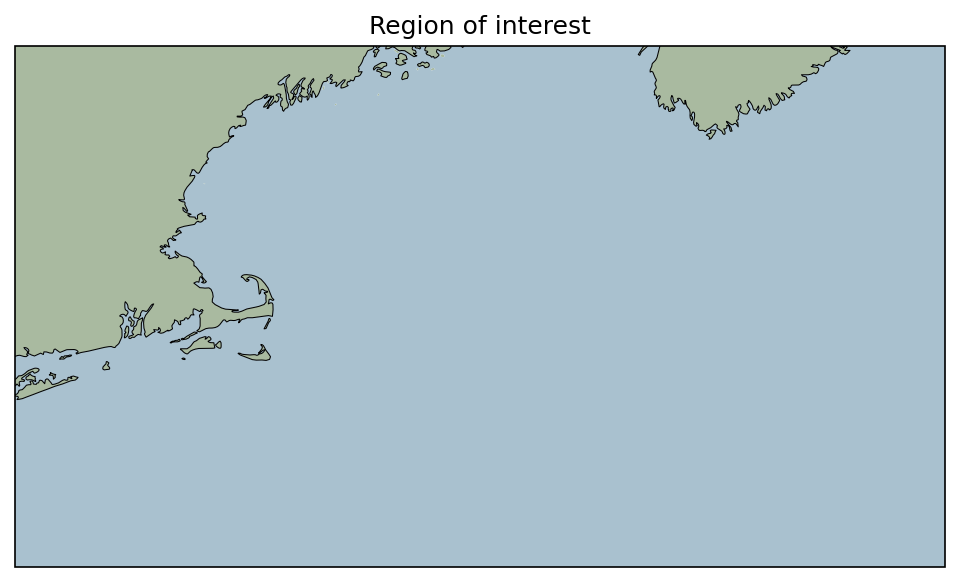

c:\Users\arrow\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\Users\arrow\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\Users\arrow\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\mpl\geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
c:\Users\arrow\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\Users\arrow\AppData\Local\Programs\Python\

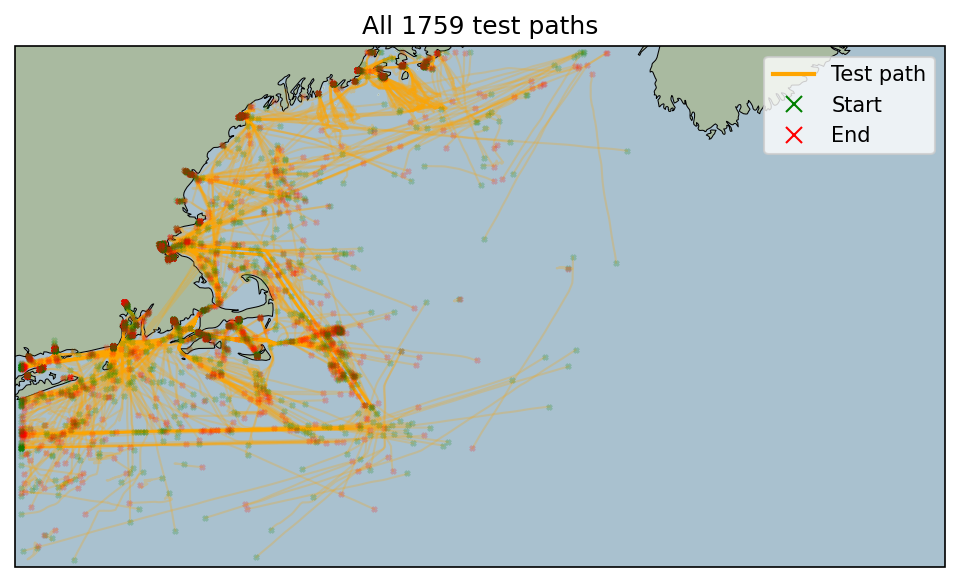

In [ ]:
# plot the whole erea and the paths
def makeOverviewPlots():
    def toLatLong(normTraj):
        lat = normTraj[..., 0] * model.lat_range + model.lat_min
        lon = normTraj[..., 1] * model.lon_range + model.lon_min
        return lat, lon

    def newCoastAx():
        plt.figure(figsize=(8,8), dpi=150)
        ax = plt.axes(projection=ccrs.PlateCarree())
        land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor="#a9baa0")
        ocean_10m = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', facecolor="#a9c1cf")
        coast_10m = cfeature.NaturalEarthFeature('physical', 'coastline', '10m', facecolor='none', edgecolor='black', linewidth=0.5)
        ax.add_feature(land_10m, zorder=0)
        ax.add_feature(ocean_10m, zorder=0)
        ax.add_feature(coast_10m, zorder=1)
        ax.set_extent([model.lon_min, model.lon_max, model.lat_min, model.lat_max], crs=ccrs.PlateCarree())
        return ax

    # just the background
    ax1 = newCoastAx()
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")
    ax1.set_title("Region of interest")
    plt.show()

    # background and paths
    ax2 = newCoastAx()
    for v in Data["test"]:
        traj = torch.tensor(v["traj"][:, :4], dtype=torch.float32)
        lat, lon = toLatLong(traj)
        ax2.plot(lon, lat, color="orange", alpha=0.25, linewidth=1, transform=ccrs.PlateCarree(), zorder=3)
        ax2.scatter(lon[0], lat[0], color="green", marker="x", s=5, alpha=0.2, zorder=4, transform=ccrs.PlateCarree())
        ax2.scatter(lon[-1], lat[-1], color="red", marker="x", s=5, alpha=0.2, zorder=4, transform=ccrs.PlateCarree())

    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")
    ax2.set_title(f"All {len(Data['test'])} test paths")
    legendElms = [
        Line2D([0], [0], color="orange", lw=2, label="Test path"),
        Line2D([0], [0], marker="x", linestyle="None", markerfacecolor="green", markeredgecolor="green", markersize=8, label="Start"),
        Line2D([0], [0], marker="x", linestyle="None", color="red", markersize=8, label="End"),
    ]
    ax2.legend(handles=legendElms)
    plt.show()
makeOverviewPlots()